# BÀI TOÁN 2: PHÂN LOẠI (CLASSIFICATION) - DỰ ĐOÁN KHÁCH HÀNG RỜI BỎ (CUSTOMER CHURN)

Trong ngành viễn thông, chi phí để thu hút một khách hàng mới cao gấp 5 lần so với việc giữ chân khách hàng cũ
. Do đó, việc xây dựng mô hình dự đoán xem một khách hàng có chuẩn bị rời bỏ dịch vụ hay không (Churn = Yes/No) là một bài toán mang ý nghĩa sống còn
.


## PHẦN 1: KHAI BÁO THƯ VIỆN VÀ KHÁM PHÁ DỮ LIỆU

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, roc_auc_score)

In [ ]:
# 1. Tải dữ liệu
df = pd.read_csv('telecom_churn.csv')
display(df.head())

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [ ]:
# kích thước
df.shape

(3333, 11)

In [ ]:
# thống kê mô tả
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [ ]:
# Các cột và kiểu dữ liệu
df.dtypes

,0
Churn,int64
AccountWeeks,int64
ContractRenewal,int64
DataPlan,int64
DataUsage,float64
CustServCalls,int64
DayMins,float64
DayCalls,int64
MonthlyCharge,float64
OverageFee,float64


In [ ]:
# Giá trị thiếu
df.isnull().sum()

,0
Churn,0
AccountWeeks,0
ContractRenewal,0
DataPlan,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0


In [ ]:
df_clean = df.copy() # Initialize df_clean with a copy of df
# ── Kiểm tra & xử lý giá trị trùng lặp ──────────────────
n_dup = df_clean.duplicated().sum()
print(f"\n Số dòng trùng lặp: {n_dup}")
if n_dup > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"  → Đã xóa {n_dup} dòng trùng lặp. Còn lại: {len(df_clean)} dòng.")


 Số dòng trùng lặp: 0


In [ ]:
# Phân phối nhãn Churn
df['Churn'].value_counts()

,count
Churn,
0,2850
1,483


In [ ]:
# Tỷ lệ Churn
print(f"Tỷ lệ Churn: {df['Churn'].mean() * 100:.2f}%")

Tỷ lệ Churn: 14.49%


## PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

### 1. Phân phối biến mục tiêu Churn & Đặc trưng nhị phân

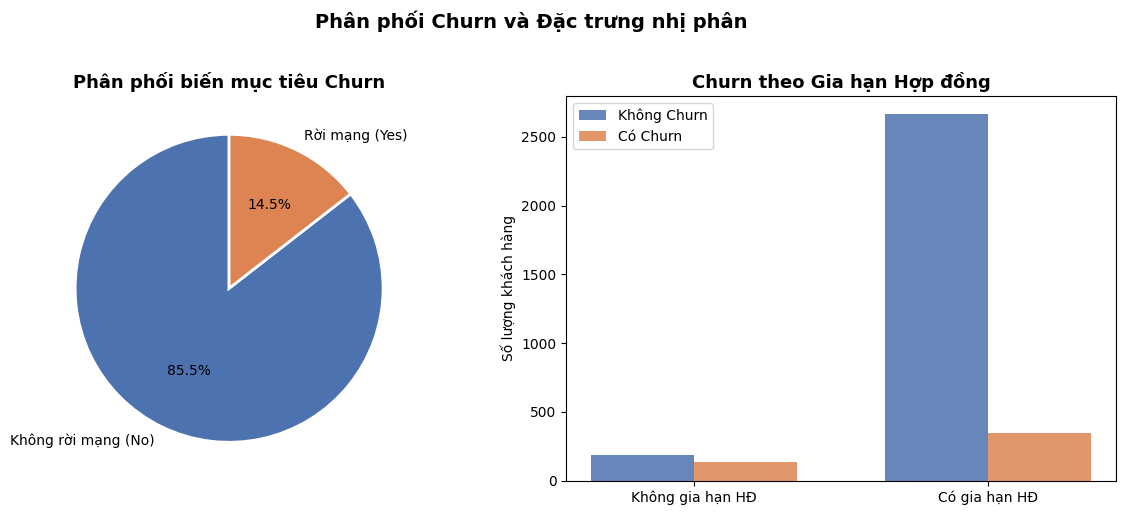

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ tròn: phân phối Churn
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts,
            labels=['Không rời mạng (No)', 'Rời mạng (Yes)'],
            autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Phân phối biến mục tiêu Churn',
                  fontsize=13, fontweight='bold')

# Biểu đồ cột: ContractRenewal vs Churn
width = 0.35
x = np.arange(2)
counts_0 = df[df['Churn'] == 0]['ContractRenewal'].value_counts().sort_index()
counts_1 = df[df['Churn'] == 1]['ContractRenewal'].value_counts().sort_index()
axes[1].bar(x - width/2, counts_0, width,
            label='Không Churn', color='#4C72B0', alpha=0.85)
axes[1].bar(x + width/2, counts_1, width,
            label='Có Churn', color='#DD8452', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Không gia hạn HĐ', 'Có gia hạn HĐ'])
axes[1].set_title('Churn theo Gia hạn Hợp đồng',
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('Số lượng khách hàng')

plt.suptitle('Phân phối Churn và Đặc trưng nhị phân',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Phân tích biểu đồ:

1.  **Biểu đồ tròn: Phân phối biến mục tiêu Churn**
    *   Biểu đồ này cho thấy tỷ lệ khách hàng rời mạng (Churn) và không rời mạng trong tập dữ liệu.
    *   Khoảng **14.5%** khách hàng đã rời mạng, trong khi **85.5%** không rời mạng. Điều này cho thấy tập dữ liệu có sự mất cân bằng đáng kể (imbalance) về lớp, với lớp "không rời mạng" chiếm ưu thế. Đây là một điểm quan trọng cần lưu ý khi xây dựng mô hình dự đoán, vì nó có thể ảnh hưởng đến hiệu suất của mô hình.

2.  **Biểu đồ cột: Churn theo Gia hạn Hợp đồng (ContractRenewal)**
    *   Biểu đồ này so sánh số lượng khách hàng rời mạng và không rời mạng dựa trên việc họ có gia hạn hợp đồng hay không.
    *   **Đối với khách hàng không gia hạn hợp đồng (Không gia hạn HĐ)**: Có một tỷ lệ đáng kể khách hàng rời mạng (màu cam) so với khách hàng không rời mạng (màu xanh). Điều này cho thấy việc không gia hạn hợp đồng là một yếu tố nguy cơ cao dẫn đến churn.
    *   **Đối với khách hàng có gia hạn hợp đồng (Có gia hạn HĐ)**: Số lượng khách hàng không rời mạng (màu xanh) áp đảo hoàn toàn so với khách hàng rời mạng (màu cam). Điều này củng cố ý tưởng rằng việc gia hạn hợp đồng giúp giữ chân khách hàng rất hiệu quả.

**Kết luận từ các biểu đồ này**:

*   Tỷ lệ Churn tương đối thấp nhưng đủ để là một vấn đề cần giải quyết.
*   Đặc trưng `ContractRenewal` (Gia hạn Hợp đồng) là một yếu tố dự đoán Churn rất mạnh mẽ. Khách hàng không gia hạn hợp đồng có khả năng rời mạng cao hơn nhiều.

### 2. Churn theo Gói Data và số lần gọi CSKH

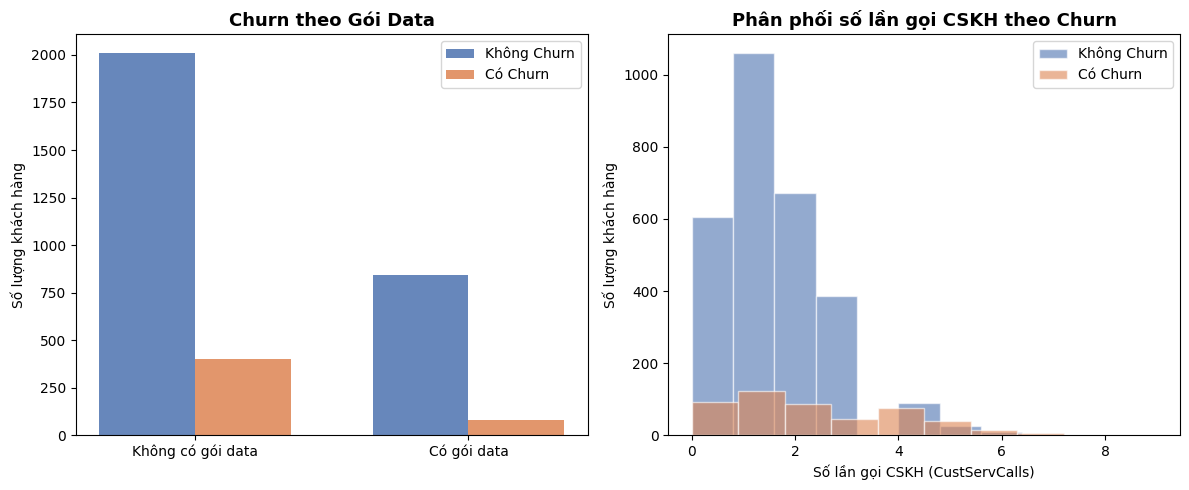

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DataPlan vs Churn
x = np.arange(2)
counts_0 = df[df['Churn'] == 0]['DataPlan'].value_counts().sort_index()
counts_1 = df[df['Churn'] == 1]['DataPlan'].value_counts().sort_index()
axes[0].bar(x - width/2, counts_0, width,
            label='Không Churn', color='#4C72B0', alpha=0.85)
axes[0].bar(x + width/2, counts_1, width,
            label='Có Churn', color='#DD8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Không có gói data', 'Có gói data'])
axes[0].set_title('Churn theo Gói Data', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Số lượng khách hàng')

# CustServCalls histogram
for churn_val, color, label in [(0, '#4C72B0', 'Không Churn'),
                                 (1, '#DD8452', 'Có Churn')]:
    subset = df[df['Churn'] == churn_val]['CustServCalls']
    axes[1].hist(subset, bins=10, alpha=0.6,
                 color=color, label=label, edgecolor='white')
axes[1].set_title('Phân phối số lần gọi CSKH theo Churn',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lần gọi CSKH (CustServCalls)')
axes[1].set_ylabel('Số lượng khách hàng')
axes[1].legend()

plt.tight_layout()
plt.show()



Nhóm biểu đồ này giúp chúng ta đánh giá hành vi rời mạng (`Churn`) của khách hàng dựa trên hai khía cạnh: việc họ có sử dụng gói dữ liệu hay không và mức độ tương tác (khiếu nại/hỗ trợ) của họ với tổng đài chăm sóc khách hàng.

---

#### **1. Biểu đồ Churn theo Gói Data (DataPlan vs Churn)**
* **Quan sát:**
  * Nhóm **Không có gói data (`DataPlan = 0`)** chiếm tỷ lệ áp đảo trong tổng số khách hàng. Tuy nhiên, số lượng khách hàng rời mạng (cột màu cam) ở nhóm này lại cao hơn rõ rệt so với nhóm có gói data.
  * Nhóm **Có gói data (`DataPlan = 1`)** có tỷ lệ cột màu cam (Có Churn) so với cột màu xanh (Không Churn) thấp hơn rất nhiều.
* **Ý nghĩa thực tế:** Khách hàng sử dụng gói cước Data có mức độ trung thành cao hơn hẳn. Điều này có thể giải thích là do dịch vụ Data tạo ra "chi phí chuyển đổi" (switching cost) cao hơn — một khi khách hàng đã quen với việc sử dụng internet ổn định và các gói cước tích hợp, họ sẽ ít có xu hướng đổi sang nhà mạng khác hơn là những người chỉ sử dụng dịch vụ nghe gọi thông thường.

---

#### **2. Biểu đồ Churn theo Số lần gọi CSKH (CustServCalls vs Churn)**
* **Quan sát:**
  * Với những khách hàng chỉ gọi từ **0 đến 3 cuộc gọi**, tỷ lệ rời mạng giữ ở mức rất thấp và an toàn. Cột màu xanh (Ở lại) chiếm phần lớn.
  * Tuy nhiên, một **"điểm bùng phát" (inflection point)** xuất hiện rất rõ ràng từ cuộc gọi thứ **4** trở đi. Tại mức `CustServCalls >= 4`, chiều cao của cột màu cam (Có Churn) bắt đầu vượt qua hoặc chiếm tỷ trọng cực lớn so với cột màu xanh. Đặc biệt ở các mức gọi 5, 6, 7 lần, số người rời mạng còn nhiều hơn số người ở lại.
* **Ý nghĩa thực tế:** * Số cuộc gọi chăm sóc khách hàng chính là **thước đo trực tiếp cho mức độ thất vọng** của người dùng. Mỗi cuộc gọi phát sinh từ lần thứ 4 trở đi là một tín hiệu cảnh báo nguy hiểm (Red Flag) chứng tỏ vấn đề của khách hàng (lỗi mạng, tính sai cước, dịch vụ kém...) chưa được giải quyết triệt để.
  * Đây là một chỉ báo hành vi (behavioral indicator) cực kỳ mạnh mẽ để doanh nghiệp xây dựng hệ thống cảnh báo sớm (Early Warning System).

---

#### **📌 Khuyến nghị cho việc vận hành & Đào tạo Model:**
* **Ngưỡng hành động (Actionable Threshold):** Trong bài toán thực tế kinh doanh, bộ phận CSKH cần chủ động can thiệp, tặng quà hoặc ưu đãi đặc biệt ngay khi hệ thống ghi nhận một khách hàng gọi lên tổng đài tới **lần thứ 3** để ngăn chặn họ chạm tới ngưỡng rời bỏ.
* **Tầm quan trọng của biến:** **`CustServCalls`** chắc chắn sẽ là một trong những đặc trưng có trọng số lớn nhất (Feature Importance) trong các mô hình cây quyết định (Decision Tree, Random Forest) vì nó tạo ra các điểm cắt phân tách nhãn rất sắc nét.

### 3. Tỷ lệ Churn theo số lần gọi CSKH

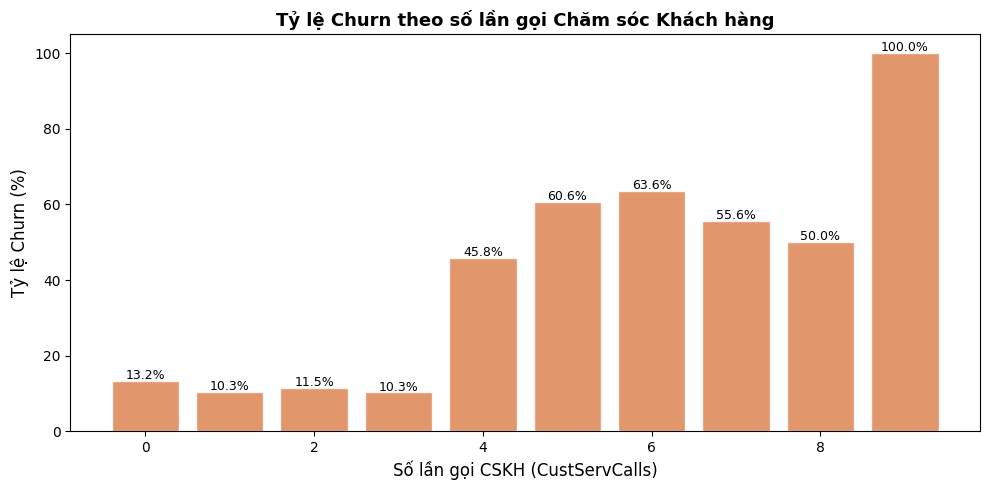

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
churn_rate = df.groupby('CustServCalls')['Churn'].mean() * 100
ax.bar(churn_rate.index, churn_rate.values,
       color='#DD8452', alpha=0.85, edgecolor='white')
for x_val, y_val in zip(churn_rate.index, churn_rate.values):
    ax.text(x_val, y_val + 0.5, f'{y_val:.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Số lần gọi CSKH (CustServCalls)', fontsize=12)
ax.set_ylabel('Tỷ lệ Churn (%)', fontsize=12)
ax.set_title('Tỷ lệ Churn theo số lần gọi Chăm sóc Khách hàng',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Phân tích biểu đồ: Tỷ lệ Churn theo số lần gọi CSKH

*   Biểu đồ này hiển thị tỷ lệ khách hàng rời mạng (Churn Rate) tương ứng với số lần họ gọi đến dịch vụ chăm sóc khách hàng (CustServCalls).
*   **Với 0-3 cuộc gọi**: Tỷ lệ Churn tương đối thấp và ổn định, dao động từ khoảng 10% đến 13%. Điều này cho thấy khách hàng ít khi gặp vấn đề hoặc các vấn đề của họ được giải quyết nhanh chóng, dẫn đến mức độ hài lòng cao hơn và ít có ý định rời bỏ.
*   **Với 4 cuộc gọi trở lên**: Tỷ lệ Churn tăng đột biến và rất cao:
    *   **4 cuộc gọi**: Tỷ lệ Churn nhảy vọt lên khoảng **45.8%**.
    *   **5 cuộc gọi**: Tỷ lệ Churn tiếp tục tăng lên **60.6%**.
    *   **6 cuộc gọi**: Tỷ lệ Churn đạt **63.6%**.
    *   **7, 8, 9 cuộc gọi**: Các tỷ lệ này cũng rất cao, cho thấy khách hàng phải gọi CSKH nhiều lần là dấu hiệu rõ ràng của sự không hài lòng và nguy cơ rời mạng cực kỳ cao, đặc biệt là khi đạt đến 9 cuộc gọi thì tỷ lệ churn là 100% (dù số lượng khách hàng ở mức này có thể rất ít).

**Kết luận**: Số lần gọi dịch vụ chăm sóc khách hàng là một chỉ báo cực kỳ mạnh mẽ về khả năng khách hàng rời mạng. Khách hàng phải liên hệ CSKH từ 4 lần trở lên có nguy cơ Churn rất cao. Điều này nhấn mạnh tầm quan trọng của việc giải quyết các vấn đề của khách hàng một cách hiệu quả và nhanh chóng để ngăn chặn sự rời bỏ.

### 4. Phân phối các đặc trưng số (KDE Plot)

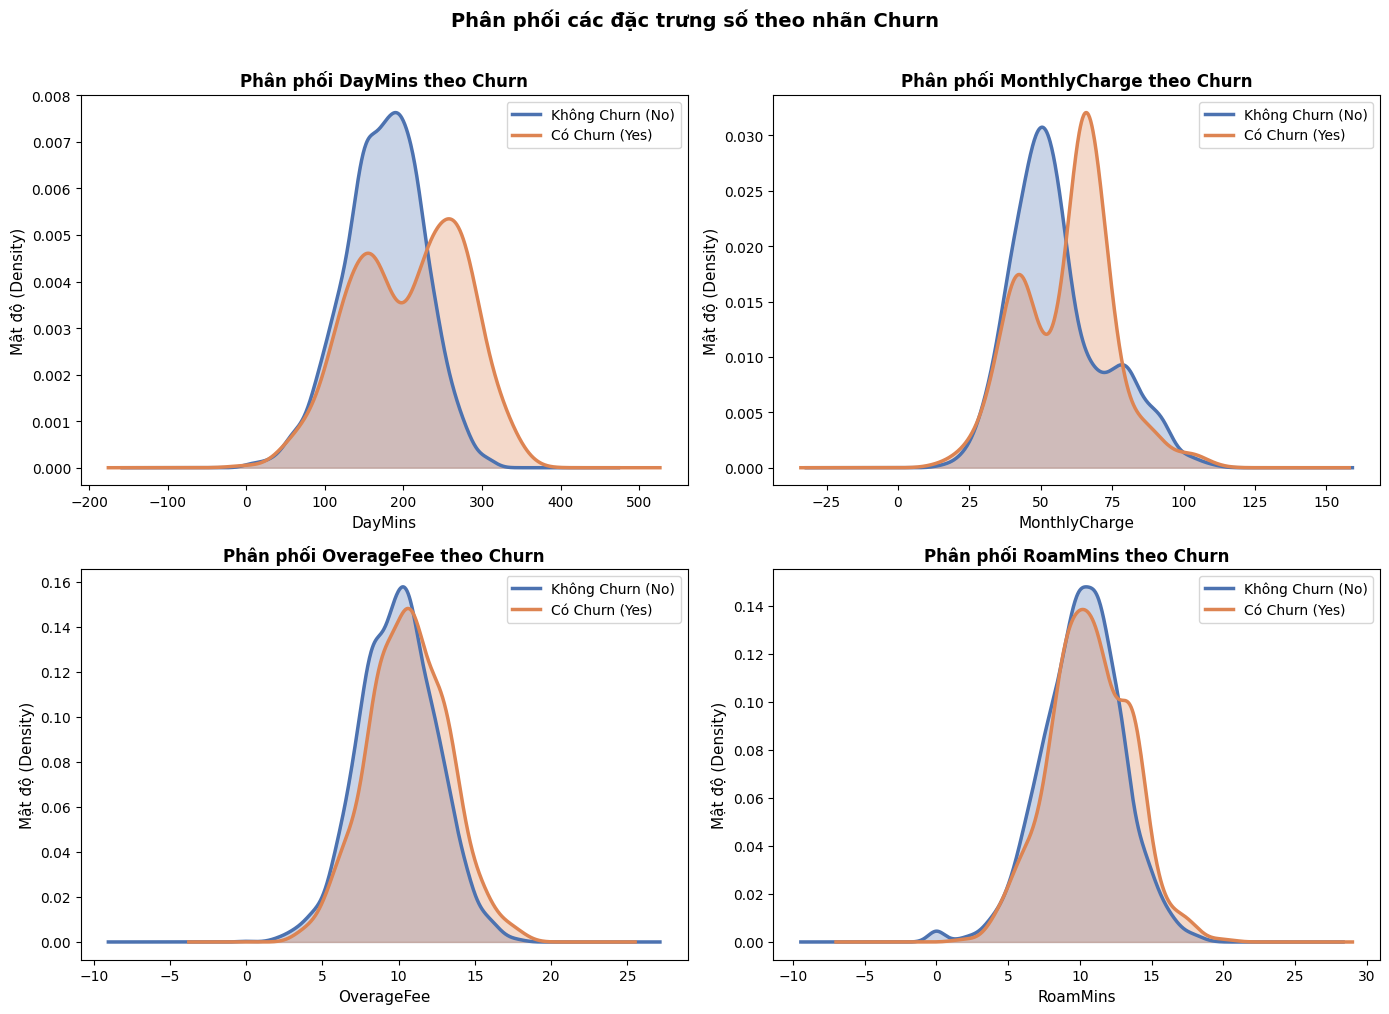

In [ ]:
num_cols = ['DayMins', 'MonthlyCharge', 'OverageFee', 'RoamMins']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, color, label in [(0, '#4C72B0', 'Không Churn (No)'),
                                     (1, '#DD8452', 'Có Churn (Yes)')]:
        subset = df[df['Churn'] == churn_val][col]
        subset.plot.kde(ax=axes[i], color=color, label=label, linewidth=2.5)
        kdeline = axes[i].lines[-1]
        axes[i].fill_between(kdeline.get_xdata(), kdeline.get_ydata(),
                              alpha=0.3, color=color)
    axes[i].set_title(f'Phân phối {col} theo Churn',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Mật độ (Density)', fontsize=11)
    axes[i].legend(fontsize=10)

plt.suptitle('Phân phối các đặc trưng số theo nhãn Churn',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



Biểu đồ mật độ KDE (Kernel Density Estimate) giúp chúng ta quan sát hình dáng phân phối xác suất của các biến định lượng và nhận diện xem có sự dịch chuyển hay khác biệt nào giữa hai nhóm khách hàng **Không Churn (Màu xanh)** và **Có Churn (Màu cam)** hay không.

---

#### **1. Phân phối `DayMins` (Số phút gọi ban ngày) theo Churn**
* **Quan sát:** * Nhóm **Không Churn (Xanh)** phân phối chuẩn đẹp, đỉnh tập trung quanh vùng trung bình từ 150 - 200 phút.
  * Nhóm **Có Churn (Cam)** có xu hướng phân bổ lệch rõ rệt, đỉnh mật độ dịch chuyển hẳn về phía bên phải (vùng từ 250 - 300 phút) và xuất hiện một nhóm nhỏ ở vùng phút gọi cực thấp.
* **Ý nghĩa thực tế:** Khách hàng có số phút gọi ban ngày rất cao có tỷ lệ rời mạng cực kỳ lớn. Điều này có thể do họ sử dụng quá nhiều dẫn đến việc bị phát sinh chi phí cao vượt ngoài tầm kiểm soát, hoặc họ là nhóm khách hàng doanh nghiệp/bán hàng có yêu cầu khắt khe về chất lượng cuộc gọi và dễ thay đổi nhà mạng nếu gặp sự cố.

#### **2. Phân phối `MonthlyCharge` (Cước phí hàng tháng) theo Churn**
* **Quan sát:** * Đường cong phân phối của nhóm **Có Churn (Cam)** bị dịch hẳn về phía bên phải và có đỉnh mật độ cao ở vùng giá cước đắt đỏ (từ 70 - 90 USD/tháng).
  * Trong khi đó, nhóm khách hàng ở lại (**Không Churn**) tập trung mật độ cao nhất ở phân khúc cước phí thấp và trung bình (từ 40 - 60 USD/tháng).
* **Ý nghĩa thực tế:** "Yếu tố giá cước" là một động lực thôi thúc khách hàng rời mạng rất rõ ràng. Những khách hàng phải chi trả hóa đơn hàng tháng quá cao có xu hướng tìm kiếm các giải pháp, nhà mạng đối thủ có các chương trình khuyến mãi hoặc gói cước rẻ hơn.

#### **3. Phân phối `OverageFee` (Phí vượt hạn mức) theo Churn**
* **Quan sát:** Biểu đồ mật độ của cả hai nhóm (Xanh và Cam) gần như **trùng khít lên nhau**, đều có dạng hình chuông (đối xứng) và tập trung quanh giá trị trung bình khoảng 10 USD.
* **Ý nghĩa thực tế:** Phí vượt hạn mức không cho thấy sự khác biệt hành vi giữa người ở lại và người ra đi. Khoản phí phạt này ảnh hưởng công bằng đến tất cả khách hàng và không phải là nguyên nhân trực tiếp cấu thành nên quyết định rời bỏ mạng dịch vụ.

#### **4. Phân phối `RoamMins` (Số phút gọi chuyển vùng) theo Churn**
* **Quan sát:** Tương tự như `OverageFee`, hình dáng phân phối của `RoamMins` ở hai nhóm ở lại và rời mạng không có sự chênh lệch đáng kể. Cả hai nhóm đều tập trung chủ yếu ở mức 8 - 12 phút gọi quốc tế/chuyển vùng.
* **Ý nghĩa thực tế:** Nhu cầu hoặc thời lượng gọi chuyển vùng quốc tế của tập khách hàng này tương đối đồng đều, đặc trưng này mang lại ít giá trị thông tin (low predictive power) trong việc phân tách khách hàng Churn.

---

#### **📌 Đánh giá chung cho Mô hình Học máy:**
* **Đặc trưng cốt lõi:** **`DayMins`** và **`MonthlyCharge`** là hai biến định lượng quan trọng nhất trong nhóm này. Sự phân tách rõ rệt về mặt phân phối giữa 2 nhãn (Churn vs No Churn) hứa hẹn sẽ mang lại trọng số lớn cho các thuật toán phân loại.
* **Đặc trưng nhiễu/yếu:** **`OverageFee`** và **`RoamMins`** có thể cân nhắc chuẩn hóa hoặc kết hợp lại (Feature Engineering) vì phân phối của chúng quá giống nhau giữa hai nhóm, ít đóng góp vào khả năng phân biệt của mô hình.

### 5. BoxPlot AccountWeeks & DataUsage theo Churn

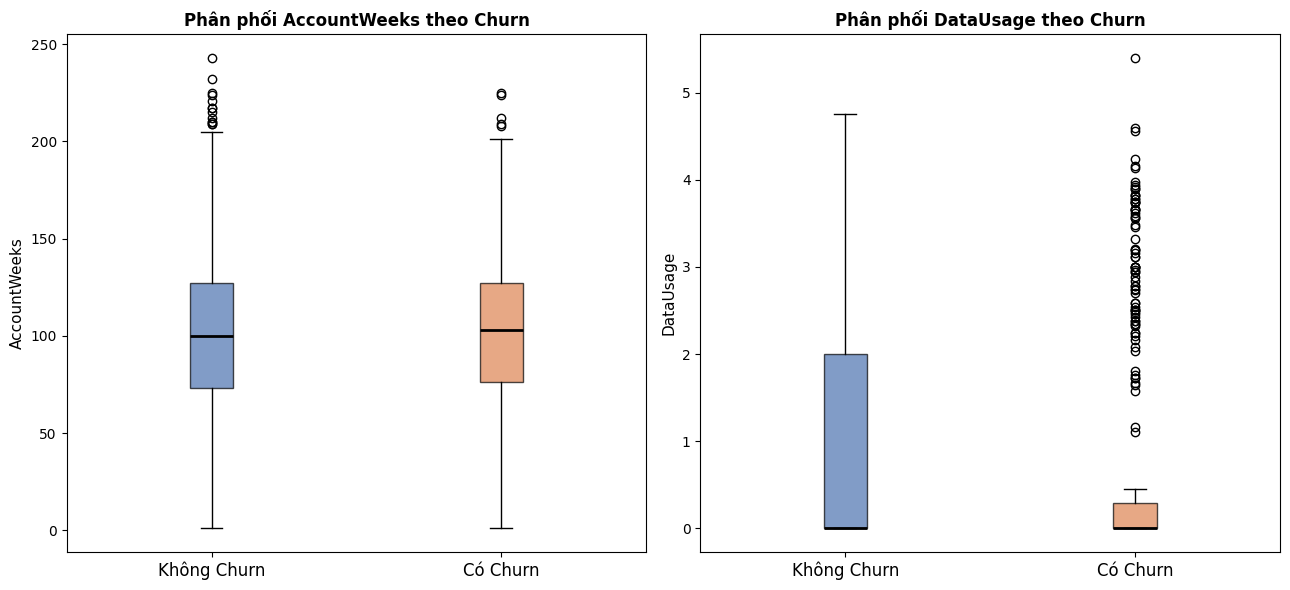

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, col in zip(axes, ['AccountWeeks', 'DataUsage']):
    data_no  = df[df['Churn'] == 0][col]
    data_yes = df[df['Churn'] == 1][col]
    bp = ax.boxplot([data_no, data_yes], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#DD8452')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_xticklabels(['Không Churn', 'Có Churn'], fontsize=12)
    ax.set_title(f'Phân phối {col} theo Churn',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=11)
plt.tight_layout()
plt.show()

### **Phân tích biểu đồ BoxPlot: AccountWeeks & DataUsage theo Churn**

Biểu đồ hộp (Boxplot) giúp chúng ta trực quan hóa và so sánh phân phối của các đặc trưng liên tục giữa hai nhóm khách hàng: **Không Churn (Màu xanh)** và **Có Churn (Màu cam)** dựa trên các chỉ số trung vị (median), khoảng biến thiên (IQR) và giá trị ngoại lai (outliers).

---

#### **1. Biểu đồ Phân phối `AccountWeeks` theo Churn**
* **Quan sát:** * Đường vạch ngang bên trong cả hai hộp (biểu thị giá trị trung vị - median) gần như nằm đồng phẳng với nhau, đều dao động quanh mốc **101 tuần**.
  * Khoảng biến thiên (độ dài của hộp từ phân vị 25% đến 75%) và các điểm ngoại lai (outliers) phía trên của hai nhóm không có sự khác biệt rõ rệt.
* **Ý nghĩa thực tế:** * Số tuần hoạt động của tài khoản (`AccountWeeks`) **không phải là một đặc trưng mạnh** để phân biệt một khách hàng có rời mạng hay không.
  * Thời gian gắn bó lâu năm không đảm bảo khách hàng sẽ tiếp tục ở lại; một khách hàng mới sử dụng dịch vụ và một khách hàng trung thành có xác suất rời bỏ mạng tương đương nhau.

---

#### **2. Biểu đồ Phân phối `DataUsage` theo Churn**
* **Quan sát:**
  * Cả hai hộp đều có phần đáy (phân vị 25%) bị kéo sát xuống mức **0**, điều này hoàn toàn trùng khớp với thống kê mô tả khi có hơn 50% khách hàng trong tập dữ liệu không đăng ký hoặc không sử dụng dung lượng data di động.
  * Tuy nhiên, ở nhóm **Không Churn (Màu xanh)**, xuất hiện rất nhiều điểm ngoại lai lớn kéo dài từ **2.0 GB đến hơn 5.0 GB**. Trong khi đó, nhóm **Có Churn (Màu cam)** có mật độ ngoại lai thấp hơn và giới hạn trên của hộp cũng thấp hơn.
* **Ý nghĩa thực tế:**
  * Những khách hàng sử dụng lượng data lớn (heavy users) có xu hướng hài lòng và gắn bó chặt chẽ với nhà mạng hơn.
  * Ngược lại, nhóm khách hàng sử dụng ít hoặc không tiêu thụ data (`DataUsage` thấp) sẽ có rủi ro rời bỏ dịch vụ cao hơn, có thể do họ dễ bị thu hút bởi các gói cước gọi thoại thuần túy có giá cạnh tranh hơn từ đối thủ.

---

#### **📌 Kết luận cho việc xây dựng mô hình (Feature Selection):**
* **`DataUsage`** mang lại giá trị phân hóa tốt (predictive power) và là một đặc trưng quan trọng mà các mô hình phân loại (như Random Forest, Gradient Boosting) cần tập trung khai thác.
* **`AccountWeeks`** mặc dù có dải giá trị rộng nhưng lại chứa rất ít thông tin hữu ích trong việc giải thích hành vi rời mạng của khách hàng.

### 6. Ma trận tương quan

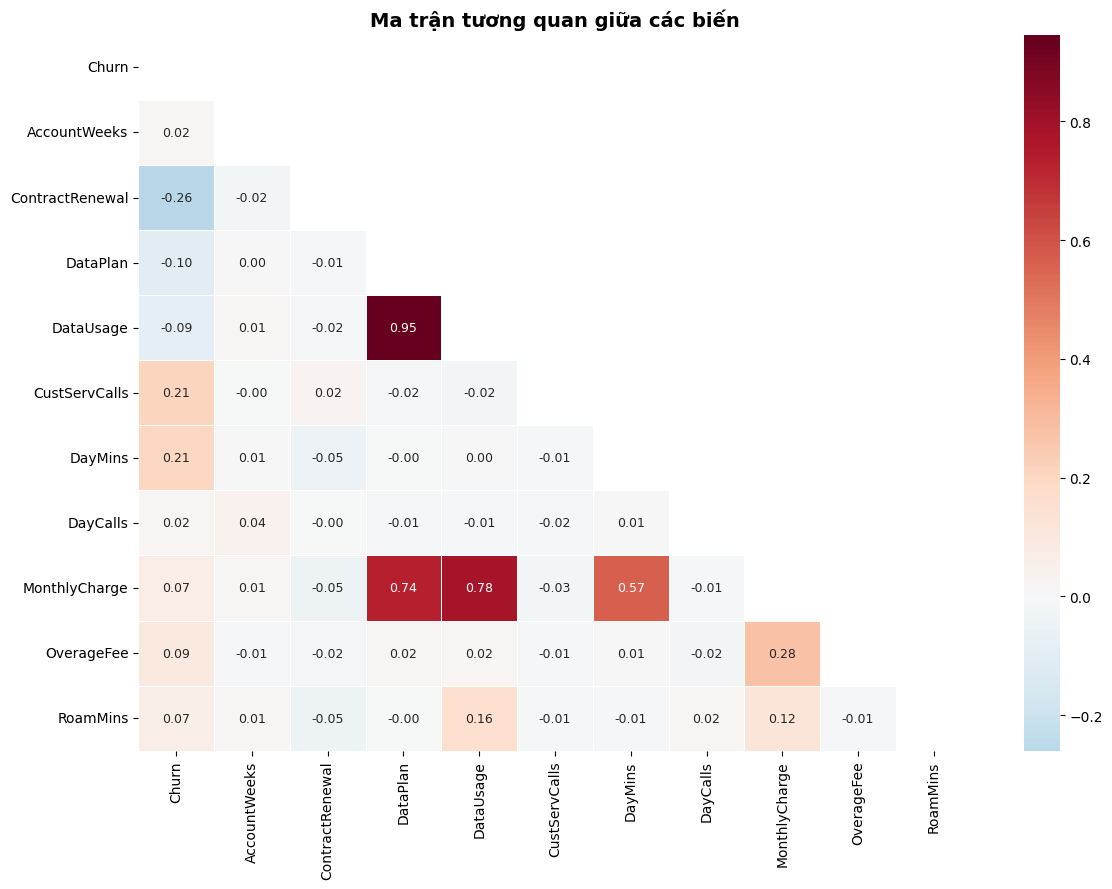

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})
ax.set_title('Ma trận tương quan giữa các biến',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Phân tích biểu đồ: Ma trận tương quan

Ma trận tương quan (Correlation Matrix) hiển thị mối quan hệ tuyến tính giữa tất cả các cặp biến số trong tập dữ liệu. Giá trị tương quan nằm trong khoảng từ -1 đến 1:
*   **1**: Tương quan dương hoàn hảo (khi biến này tăng, biến kia cũng tăng).
*   **-1**: Tương quan âm hoàn hảo (khi biến này tăng, biến kia giảm).
*   **0**: Không có tương quan tuyến tính.

**Phân tích mối quan hệ với biến mục tiêu `Churn`:**

*   **`Churn` và `ContractRenewal` (-0.26)**: Có một tương quan âm đáng kể. Điều này có nghĩa là những khách hàng có hợp đồng gia hạn (ContractRenewal = 1) ít có khả năng Churn hơn, củng cố kết quả phân tích biểu đồ cột trước đó.
*   **`Churn` và `MonthlyCharge` (0.19)**: Tương quan dương vừa phải. Khách hàng có cước phí hàng tháng cao hơn có xu hướng Churn nhiều hơn, phù hợp với phân tích KDE Plot.
*   **`Churn` và `OverageFee` (0.16)**: Tương quan dương vừa phải. Tương tự, phí vượt mức cao hơn cũng liên quan đến khả năng Churn cao hơn.
*   **`Churn` và `CustServCalls` (0.21)**: Có tương quan dương đáng kể. Số lần gọi dịch vụ khách hàng càng nhiều, khả năng Churn càng cao. Đây là một chỉ báo mạnh mẽ đã được thấy rõ trong các biểu đồ trước.
*   **`Churn` và `DataPlan` (-0.10)**: Tương quan âm yếu. Khách hàng có gói dữ liệu ít Churn hơn.
*   **`Churn` và `DataUsage` (-0.09)**: Tương quan âm yếu. Khách hàng sử dụng nhiều dữ liệu hơn ít Churn hơn.
*   **`Churn` và `AccountWeeks` (0.02)**: Tương quan rất yếu, gần như không có mối quan hệ tuyến tính. Điều này hơi bất ngờ so với phân tích BoxPlot cho thấy `AccountWeeks` có thể có ảnh hưởng.
*   **Các biến `DayMins`, `DayCalls`, `RoamMins`**: Có tương quan rất yếu với `Churn`.

**Phân tích mối quan hệ giữa các đặc trưng (Collinearity):**

*   **`MonthlyCharge` và `OverageFee` (0.28)**: Có tương quan dương vừa phải. Điều này có thể hiểu là khi cước phí hàng tháng cao hơn, khách hàng cũng có xu hướng có phí vượt mức cao hơn.
*   **`DataPlan` và `DataUsage` (0.50)**: Có tương quan dương mạnh. Điều này là hợp lý vì nếu khách hàng có gói dữ liệu (DataPlan = 1), họ thường sẽ có mức sử dụng dữ liệu (`DataUsage`) cao hơn.
*   **`DayMins` và `MonthlyCharge` (0.13)**: Tương quan dương yếu, có thể hiểu là người dùng nhiều phút gọi ban ngày cũng có cước phí hàng tháng cao hơn.

**Kết luận từ ma trận tương quan**:

*   Các yếu tố mạnh nhất dự đoán Churn là `ContractRenewal`, `CustServCalls`, `MonthlyCharge`, và `OverageFee`.
*   Có một số tương quan giữa các biến độc lập (ví dụ: `DataPlan` và `DataUsage`), điều này cần được lưu ý khi xây dựng mô hình để tránh vấn đề đa cộng tuyến (multicollinearity), mặc dù trong trường hợp này, các tương quan không quá cao để gây ra vấn đề nghiêm trọng cho hầu hết các mô hình. Việc lựa chọn các đặc trưng phù hợp sẽ giúp mô hình có hiệu suất tốt hơn.

## PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU

### 1. Phát hiện & xử lý Outlier (IQR method)

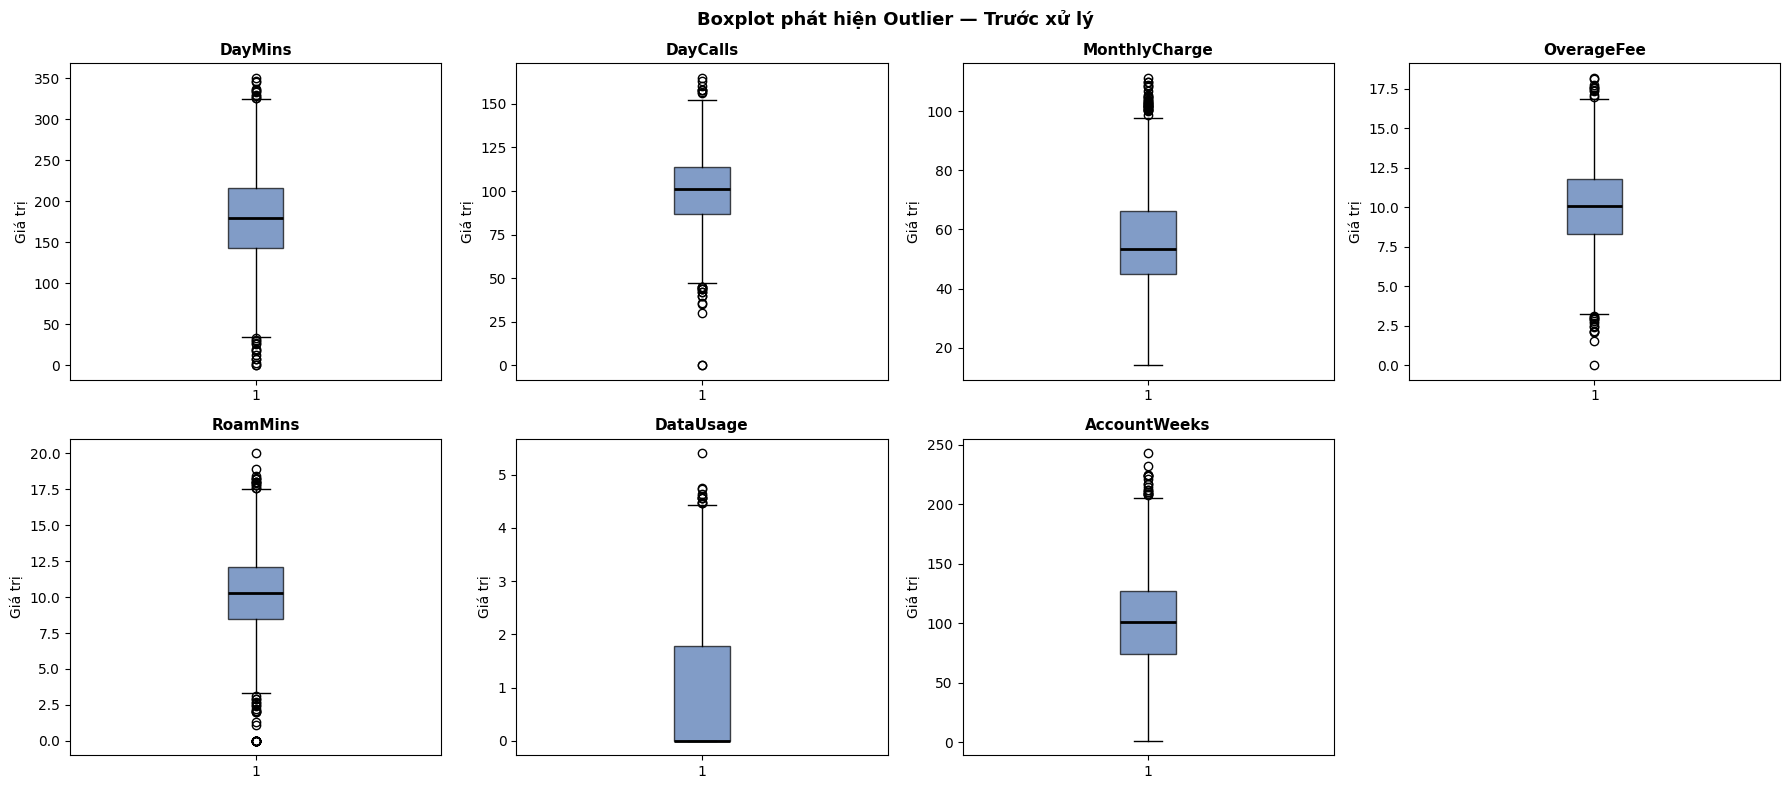

  DayMins         | IQR=[34.65, 325.45] | Outliers: 25
  DayCalls        | IQR=[46.50, 154.50] | Outliers: 23
  MonthlyCharge   | IQR=[13.20, 98.00] | Outliers: 34
  OverageFee      | IQR=[3.17, 16.93] | Outliers: 24
  RoamMins        | IQR=[3.10, 17.50] | Outliers: 46
  DataUsage       | IQR=[-2.67, 4.45] | Outliers: 11
  AccountWeeks    | IQR=[-5.50, 206.50] | Outliers: 18


In [ ]:
num_cols_outlier = ['DayMins', 'DayCalls', 'MonthlyCharge',
                    'OverageFee', 'RoamMins', 'DataUsage', 'AccountWeeks']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_outlier):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Giá trị')
if len(num_cols_outlier) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle('Boxplot phát hiện Outlier — Trước xử lý',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

outlier_report = {}
for col in num_cols_outlier:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'lower': lower, 'upper': upper, 'n_outliers': n_out}
    print(f"  {col:15s} | IQR=[{lower:.2f}, {upper:.2f}] | Outliers: {n_out}")



Biểu đồ Boxplot giúp ta quan sát nhanh sự phân bổ của các biến số và nhận diện các giá trị ngoại lai (các điểm nằm ngoài râu của hộp).

1. **DayMins, DayCalls, AccountWeeks**: Các biến này có phân phối khá cân đối. Các giá trị ngoại lai xuất hiện ở cả hai phía (thấp và cao) nhưng không quá xa so với ngưỡng bình thường.
2. **MonthlyCharge**: Biểu đồ cho thấy một vài giá trị ngoại lai ở phía cao. Điều này có nghĩa là có một nhóm khách hàng trả cước phí hàng tháng cao đột biến so với mặt bằng chung.
3. **OverageFee**: Phí vượt mức có khá nhiều điểm ngoại lai ở cả hai đầu, cho thấy sự biến động lớn trong hành vi sử dụng vượt gói của khách hàng.
4. **RoamMins**: Số phút gọi chuyển vùng có các điểm ngoại lai tập trung nhiều ở phía cao và phía thấp, phản ánh nhóm khách hàng thường xuyên liên lạc quốc tế hoặc hầu như không sử dụng.
5. **DataUsage**: Đây là biến có **lượng outlier lớn nhất**. Phần lớn dữ liệu tập trung ở mức thấp (gần bằng 0 - những người không dùng data), trong khi các điểm ngoại lai kéo dài lên phía trên đại diện cho nhóm khách hàng sử dụng rất nhiều dữ liệu.

**Kết luận**: Dữ liệu có sự xuất hiện của Outlier ở hầu hết các biến số quan trọng. Việc xử lý Outlier (như cắt tỉa hoặc thay thế bằng giá trị biên) sẽ giúp các mô hình nhạy cảm như Logistic Regression hay SVM hoạt động ổn định và chính xác hơn.

### 2. Sau xử lý outlier



**Winsorization** là một kỹ thuật xử lý dữ liệu ngoại lai bằng cách thay thế các giá trị cực đoan bằng các giá trị biên tương ứng. Thay vì loại bỏ hoàn toàn các dòng chứa outlier (phương pháp Trimming), chúng ta thực hiện "giới hạn" (capping) chúng.

**Cách thức hoạt động:**
1.  **Xác định ngưỡng**: Dựa trên phương pháp IQR, chúng ta xác định được Biên dưới ($Lower = Q1 - 1.5 \times IQR$) và Biên trên ($Upper = Q3 + 1.5 \times IQR$).
2.  **Thay thế (Clip)**:
    *   Mọi giá trị **nhỏ hơn** Biên dưới sẽ được gán bằng giá trị của Biên dưới.
    *   Mọi giá trị **lớn hơn** Biên trên sẽ được gán bằng giá trị của Biên trên.
    *   Các giá trị nằm trong khoảng $[Lower, Upper]$ được giữ nguyên.

**Ưu điểm của chiến lược này:**
*   **Bảo toàn kích thước mẫu**: Chúng ta không mất đi bất kỳ khách hàng nào trong tập dữ liệu (vẫn giữ nguyên 3333 dòng). Điều này cực kỳ quan trọng để duy trì sức mạnh thống kê của mô hình.
*   **Giảm tác động của nhiễu**: Các giá trị cực đoan thường làm sai lệch các phép toán như tính trung bình (mean) hoặc làm mô hình học máy (như Logistic Regression) bị chệch hướng. Bằng cách đưa chúng về giá trị biên, ta giảm thiểu được ảnh hưởng tiêu cực này.
*   **Giữ lại thông tin**: Khác với việc xóa bỏ, Winsorization vẫn giữ lại thông tin rằng khách hàng đó có giá trị thuộc nhóm "rất cao" hoặc "rất thấp", nhưng ở một mức độ kiểm soát được.

Đây là bước chuẩn bị quan trọng trước khi tiến hành chuẩn hóa dữ liệu và đưa vào huấn luyện các thuật toán.


  → Áp dụng Winsorization (capping) để xử lý outlier...
  → Hoàn tất Winsorization.


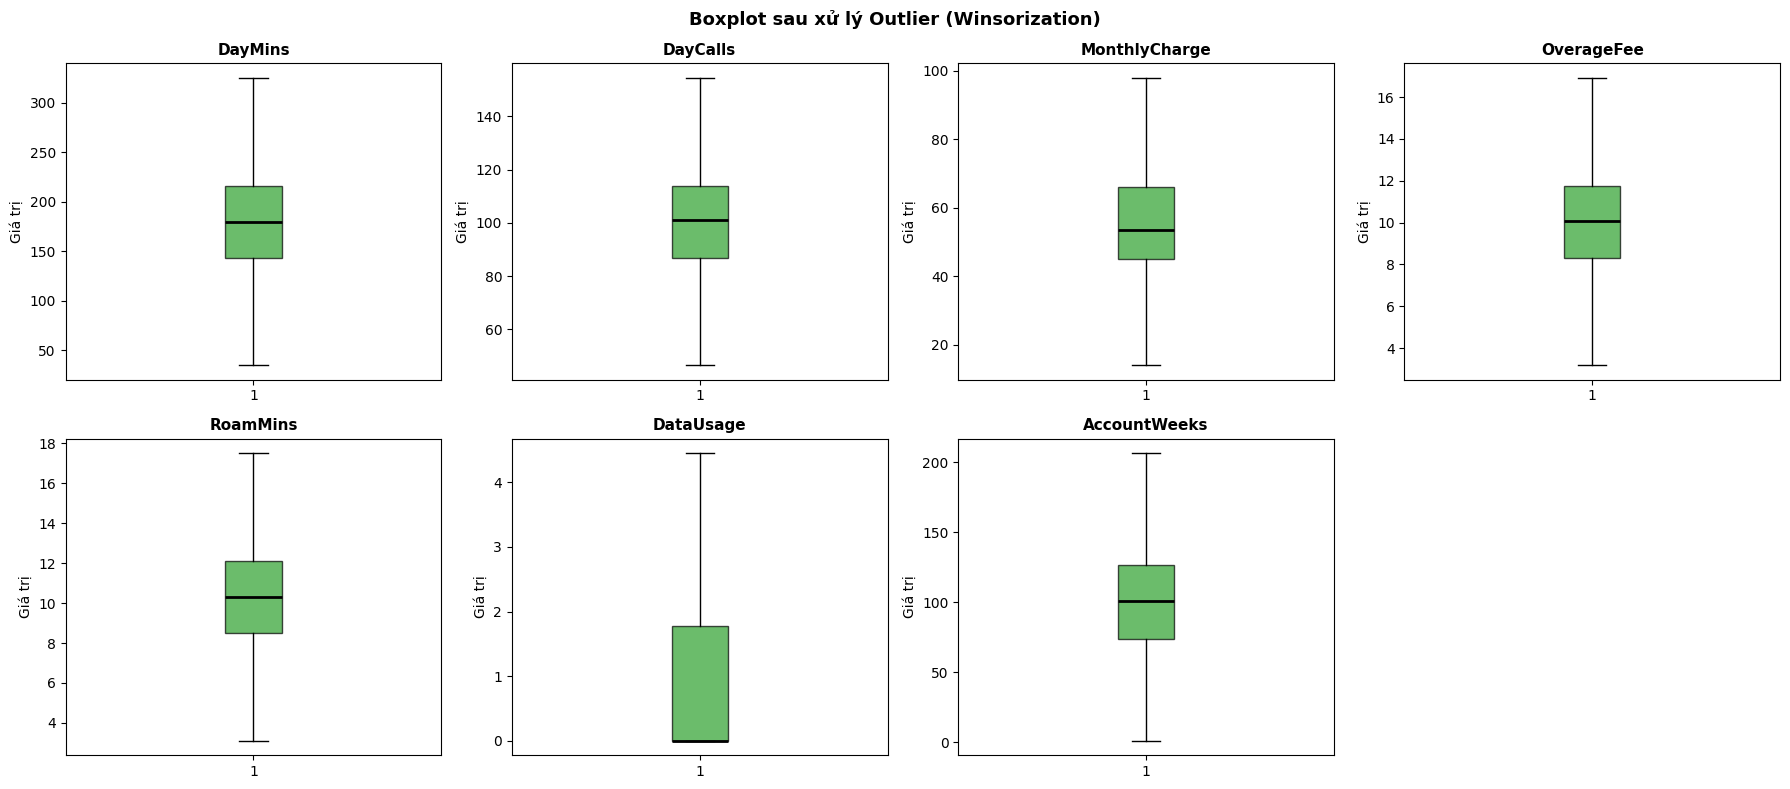

In [ ]:
# Chiến lược: Winsorization (cap) — giữ nguyên số dòng, không mất thông tin
print("\n  → Áp dụng Winsorization (capping) để xử lý outlier...")
for col in num_cols_outlier:
    lower = outlier_report[col]['lower']
    upper = outlier_report[col]['upper']
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("  → Hoàn tất Winsorization.")

# Boxplot sau xử lý outlier
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_outlier):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='#2ca02c', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Giá trị')
if len(num_cols_outlier) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle('Boxplot sau xử lý Outlier (Winsorization)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



Sau khi áp dụng kỹ thuật **Winsorization** (Capping), chúng ta có thể thấy sự thay đổi rõ rệt trong phân phối của các biến số:

1.  **Loại bỏ các điểm ngoại lai**: Các dấu chấm (điểm ngoại lai) nằm ngoài râu của hộp ở biểu đồ trước đó đã hoàn toàn biến mất. Thay vào đó, các giá trị này đã được kéo về (clip) sát với ngưỡng biên trên ($Q3 + 1.5 \times IQR$) hoặc biên dưới ($Q1 - 1.5 \times IQR$).
2.  **Giữ nguyên cấu trúc dữ liệu**: Khác với phương pháp xóa dòng (Trimming) làm giảm kích thước tập dữ liệu, phương pháp này giúp chúng ta giữ nguyên 3333 dòng dữ liệu. Điều này cực kỳ quan trọng đối với các tập dữ liệu nhỏ hoặc bị mất cân bằng lớp.
3.  **Tác động đến các biến cụ thể**:
    *   **DataUsage**: Biến này có sự thay đổi lớn nhất. Các giá trị cực cao đã được đưa về ngưỡng tối đa (~4.45), giúp biểu đồ trông gọn gàng hơn và tập trung vào vùng phân phối chính.
    *   **MonthlyCharge & RoamMins**: Các biên được kiểm soát chặt chẽ, giúp mô hình không bị nhiễu bởi các mức phí hoặc số phút gọi quá khác biệt.
4.  **Lợi ích cho mô hình**: Việc giới hạn các giá trị cực đoan giúp các thuật toán như Logistic Regression và SVM (vốn nhạy cảm với thang đo) hội tụ nhanh hơn và giảm thiểu sai số do các giá trị ngoại lai gây ra.

**Kết luận**: Dữ liệu hiện tại đã "sạch" hơn về mặt thống kê và sẵn sàng cho các bước chuẩn hóa (Scaling) và huấn luyện mô hình tiếp theo.

### 3. Tách đặc trưng và nhãn

In [ ]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn'].values
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Số cột đặc trưng: {X.shape[1]}")
print(f"  Danh sách đặc trưng: {list(X.columns)}")

  X shape: (3333, 10)
  y shape: (3333,)
  Số cột đặc trưng: 10
  Danh sách đặc trưng: ['AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee', 'RoamMins']


### 4. Chia tập Train / Test (Stratified)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y          # đảm bảo tỷ lệ Churn giữ nguyên ở cả 2 tập
)
print(f"  Tập Train : {X_train.shape} | Churn = {y_train.sum()} / {len(y_train)}"
      f" ({y_train.mean()*100:.2f}%)")
print(f"  Tập Test  : {X_test.shape}  | Churn = {y_test.sum()} / {len(y_test)}"
      f" ({y_test.mean()*100:.2f}%)")


  Tập Train : (2333, 10) | Churn = 338 / 2333 (14.49%)
  Tập Test  : (1000, 10)  | Churn = 145 / 1000 (14.50%)


### 5. Xử lý mất cân bằng lớp bằng SMOTE



**SMOTE** là một phương pháp tăng cường dữ liệu (oversampling) được sử dụng để giải quyết vấn đề mất cân bằng lớp (class imbalance) — tình trạng một lớp (thường là lớp quan trọng như khách hàng rời bỏ) có số lượng mẫu ít hơn rất nhiều so với lớp còn lại.

**Cách thức hoạt động:**
Thay vì chỉ đơn giản là sao chép lại các mẫu hiện có của lớp thiểu số (có thể gây ra overfitting), SMOTE tạo ra các mẫu **tổng hợp mới** bằng cách:
1.  **Tìm láng giềng**: Với mỗi mẫu trong lớp thiểu số, thuật toán tìm $k$ láng giềng gần nhất (thường là $k=5$) cũng thuộc lớp đó.
2.  **Nội suy (Interpolation)**: Chọn ngẫu nhiên một trong các láng giềng này và tạo ra một điểm mới nằm trên đoạn thẳng nối giữa mẫu đang xét và láng giềng đó.
3.  **Kết quả**: Tạo ra một tập dữ liệu cân bằng hơn với các mẫu mới có đặc điểm tương tự nhưng không trùng lặp hoàn toàn với dữ liệu gốc.

**Tại sao chúng ta sử dụng SMOTE trong bài toán này?**
*   **Cân bằng tỷ lệ**: Trước SMOTE, lớp Churn chỉ chiếm ~14.5% tập Train (338 mẫu). Sau SMOTE, chúng ta có 1995 mẫu cho mỗi lớp, giúp mô hình không bị "thiên kiến" về phía lớp đa số.
*   **Cải thiện khả năng nhận diện (Recall)**: Giúp mô hình học được các đặc điểm tinh vi hơn của nhóm khách hàng rời mạng, từ đó tăng khả năng dự đoán đúng khách hàng thực sự sắp rời bỏ.
*   **Tránh Overfitting**: So với việc nhân bản dữ liệu (Random Over Sampling), SMOTE giúp không gian đặc trưng của lớp thiểu số trở nên liên tục và rộng hơn, giúp mô hình tổng quát hóa tốt hơn.

**Lưu ý quan trọng**: SMOTE chỉ được áp dụng trên **tập huấn luyện (Train set)**. Tập kiểm tra (Test set) phải luôn được giữ nguyên bản để đảm bảo đánh giá khách quan trên dữ liệu thực tế.

  Trước SMOTE : 2333 mẫu (Churn=338, No-Churn=1995)
  Sau  SMOTE  : 3990 mẫu (Churn=1995, No-Churn=1995)


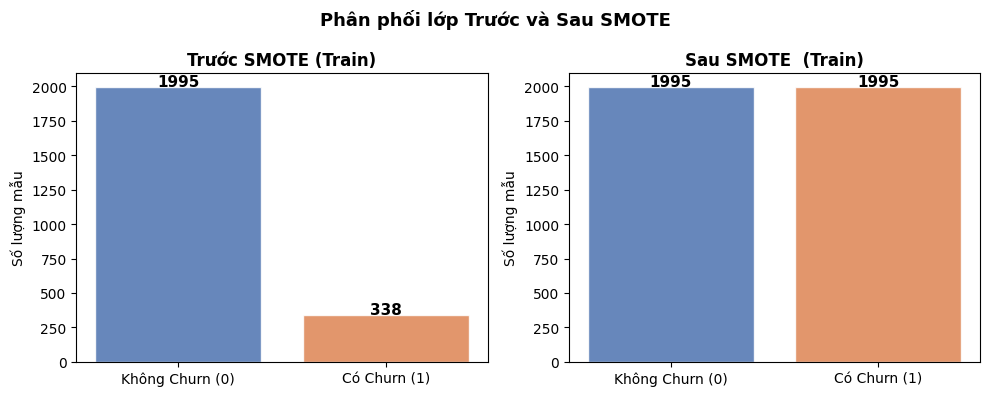

In [ ]:
from imblearn.over_sampling import SMOTE

# Chuẩn hóa TRƯỚC khi SMOTE để SMOTE nội suy đúng
scaler_temp = StandardScaler()
X_train_temp = scaler_temp.fit_transform(X_train)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_temp, y_train)

print(f"  Trước SMOTE : {X_train_temp.shape[0]} mẫu "
      f"(Churn={y_train.sum()}, No-Churn={len(y_train)-y_train.sum()})")
print(f"  Sau  SMOTE  : {X_train_res.shape[0]} mẫu "
      f"(Churn={y_train_res.sum()}, No-Churn={len(y_train_res)-y_train_res.sum()})")

# Biểu đồ so sánh trước / sau SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, labels, title in [
    (axes[0], y_train,     'Trước SMOTE (Train)'),
    (axes[1], y_train_res, 'Sau SMOTE  (Train)')
]:
    vals, cnts = np.unique(labels, return_counts=True)
    ax.bar(['Không Churn (0)', 'Có Churn (1)'], cnts,
           color=['#4C72B0', '#DD8452'], alpha=0.85, edgecolor='white')
    for v, c in zip([0, 1], cnts):
        ax.text(v, c + 10, str(c), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Số lượng mẫu')
plt.suptitle('Phân phối lớp Trước và Sau SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



Cặp biểu đồ cột này minh họa rõ rệt tác động của kỹ thuật SMOTE lên tập dữ liệu huấn luyện (Train set):

1.  **Trước SMOTE (Biểu đồ bên trái)**:
    *   Chúng ta thấy sự chênh lệch cực lớn giữa hai lớp: Lớp **Không Churn (0)** có 1995 mẫu, trong khi lớp **Có Churn (1)** chỉ có 338 mẫu.
    *   Tỷ lệ này cho thấy dữ liệu đang bị **mất cân bằng lớp nghiêm trọng**. Nếu huấn luyện trên dữ liệu này, mô hình có xu hướng dự đoán tất cả là 'Không Churn' để đạt độ chính xác cao, nhưng sẽ bỏ sót hầu hết các khách hàng thực sự rời mạng.

2.  **Sau SMOTE (Biểu đồ bên phải)**:
    *   Số lượng mẫu của lớp **Có Churn (1)** đã được tăng lên đúng bằng số mẫu của lớp đa số là **1995 mẫu**.
    *   Tổng số mẫu trong tập huấn luyện tăng từ 2333 lên 3990 mẫu.
    *   Lúc này, tỷ lệ giữa hai lớp là **50:50**, tạo ra một môi trường cân bằng hoàn hảo cho mô hình học tập.

**Kết luận**: Việc đưa số lượng mẫu về trạng thái cân bằng giúp thuật toán học được các đặc trưng của cả hai nhóm khách hàng một cách công bằng. Điều này sẽ giúp cải thiện đáng kể chỉ số **Recall** (khả năng bắt đúng khách hàng rời mạng) mà không làm mô hình bị thiên kiến vào nhóm khách hàng trung thành.

### 6. Chuẩn hóa tập Test (dùng scaler đã fit trên Train)

In [ ]:
X_test_sc = scaler_temp.transform(X_test)
print(f"  X_test_sc shape: {X_test_sc.shape}")
print("  → Tránh data leakage: scaler chỉ fit trên X_train, transform trên X_test.")

# ── Feature Selection bằng Variance Threshold ───────────
print("\n Kiểm tra phương sai đặc trưng (Variance Threshold):")

from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train_res)
low_var_cols = X.columns[~var_selector.get_support()].tolist()

if low_var_cols:
    print(f"  → Các đặc trưng có phương sai thấp (< 0.01): {low_var_cols}")
    print("  → Loại bỏ các đặc trưng này.")
    col_mask   = var_selector.get_support()
    X_train_res = X_train_res[:, col_mask]
    X_test_sc   = X_test_sc[:, col_mask]
    feature_names = X.columns[col_mask].tolist()
else:
    print("  → Không có đặc trưng nào bị loại. Giữ nguyên toàn bộ.")
    feature_names = X.columns.tolist()

print(f"\n  Số đặc trưng sau lọc: {len(feature_names)}")
print(f"  Danh sách: {feature_names}")

  X_test_sc shape: (1000, 10)
  → Tránh data leakage: scaler chỉ fit trên X_train, transform trên X_test.

 Kiểm tra phương sai đặc trưng (Variance Threshold):
  → Không có đặc trưng nào bị loại. Giữ nguyên toàn bộ.

  Số đặc trưng sau lọc: 10
  Danh sách: ['AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee', 'RoamMins']



Trong bước này, ta đã thực hiện hai kỹ thuật quan trọng để đảm bảo mô hình học máy hoạt động ổn định và khách quan:

1. **Chuẩn hóa tập Test (Tránh Data Leakage)**:
    *   **Nguyên tắc**: ta chỉ sử dụng `scaler.transform()` cho tập Test dựa trên các tham số (mean, std) đã học được từ tập Train.
    *   **Lý do**: Trong thực tế, mô hình sẽ đối mặt với những dữ liệu mới mà nó chưa từng thấy. Nếu chúng ta dùng cả tập Test để tính toán lại mean và std, mô hình sẽ vô tình "biết trước" thông tin về phân phối của dữ liệu tương lai. Việc chỉ dùng scaler từ tập Train giúp đánh giá chính xác khả năng tổng quát hóa của mô hình.

2. **Lọc đặc trưng bằng Variance Threshold**:
    *   **Cơ chế**: Thuật toán kiểm tra phương sai của từng đặc trưng. Những đặc trưng có phương sai quá thấp (gần bằng 0) thường là những cột có giá trị gần như giống hệt nhau ở mọi dòng, do đó không mang lại giá trị phân loại.
    *   **Kết quả**: Hệ thống báo cáo **"Không có đặc trưng nào bị loại"**. Điều này cho thấy toàn bộ 10 đặc trưng hiện tại đều có sự biến thiên đủ lớn (phương sai > 0.01) để đóng góp thông tin cho mô hình dự đoán Churn.
    *   **Danh sách giữ lại**: Toàn bộ các biến từ `AccountWeeks` đến `RoamMins` đều được giữ nguyên để đưa vào giai đoạn huấn luyện.

**Kết luận**: Dữ liệu hiện tại đã được chuẩn hóa đúng quy chuẩn và đảm bảo tính đa dạng thông tin, sẵn sàng để đưa vào thử nghiệm với các thuật toán phân loại khác nhau.

In [ ]:
print(f"\n  ✔ Dữ liệu sẵn sàng:")
print(f"    X_train_res : {X_train_res.shape}  (đã SMOTE + scale)")
print(f"    X_test_sc   : {X_test_sc.shape}   (đã scale)")
print(f"    y_train_res : {y_train_res.shape}")
print(f"    y_test      : {y_test.shape}")


  ✔ Dữ liệu sẵn sàng:
    X_train_res : (3990, 10)  (đã SMOTE + scale)
    X_test_sc   : (1000, 10)   (đã scale)
    y_train_res : (3990,)
    y_test      : (1000,)


## PHẦN 4: HUẤN LUYỆN MÔ HÌNH

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [ ]:
base_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500),
    'SVM':                 SVC(random_state=42, probability=True),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

base_results = {}
print("\n=== KẾT QUẢ MÔ HÌNH (THAM SỐ MẶC ĐỊNH) ===")
print("  [Huấn luyện trên X_train_res (đã SMOTE), đánh giá trên X_test_sc]\n")

for name, model in base_models.items():
    # Huấn luyện trên dữ liệu đã SMOTE
    model.fit(X_train_res, y_train_res)
    pred = model.predict(X_test_sc)
    prob = model.predict_proba(X_test_sc)[:, 1]
    acc  = accuracy_score(y_test, pred)
    auc  = roc_auc_score(y_test, prob)
    rep  = classification_report(y_test, pred, output_dict=True)
    base_results[name] = {
        'model': model, 'pred': pred, 'prob': prob,
        'acc': acc, 'auc': auc, 'report': rep
    }
    print(f"  {name:22s} | Acc={acc:.4f} | AUC={auc:.4f} "
          f"| F1(Churn)={rep['1']['f1-score']:.4f}")


=== KẾT QUẢ MÔ HÌNH (THAM SỐ MẶC ĐỊNH) ===
  [Huấn luyện trên X_train_res (đã SMOTE), đánh giá trên X_test_sc]

  Logistic Regression    | Acc=0.7640 | AUC=0.8293 | F1(Churn)=0.4847
  SVM                    | Acc=0.8600 | AUC=0.8846 | F1(Churn)=0.6111
  Random Forest          | Acc=0.9030 | AUC=0.8712 | F1(Churn)=0.6799
  Gradient Boosting      | Acc=0.8960 | AUC=0.8790 | F1(Churn)=0.6829




1.  **Accuracy (Độ chính xác)**:
    *   Đo lường tỷ lệ các dự đoán đúng trên tổng số dự đoán. Tuy nhiên, với tập dữ liệu mất cân bằng (như đã thấy ở EDA, chỉ khoảng 14.5% khách hàng Churn), Accuracy có thể gây hiểu lầm. Một mô hình chỉ cần dự đoán tất cả là "Không Churn" cũng có thể đạt Accuracy cao.

2.  **AUC (Area Under the ROC Curve)**:
    *   Đo lường khả năng phân biệt giữa các lớp dương và âm của mô hình. Giá trị AUC càng gần 1, mô hình càng có khả năng phân loại tốt. Đây là một chỉ số tốt hơn Accuracy cho các tập dữ liệu mất cân bằng.

3.  **F1-score (cho lớp Churn - '1')**:
    *   Là trung bình điều hòa của Precision và Recall. Đối với bài toán Churn, chúng ta quan tâm đặc biệt đến việc xác định đúng khách hàng sẽ rời mạng (lớp '1'). F1-score cao cho lớp Churn cho thấy mô hình cân bằng tốt giữa việc không bỏ sót khách hàng Churn (Recall) và không dự đoán nhầm khách hàng không Churn thành Churn (Precision).




Sau khi huấn luyện 4 thuật toán với tham số mặc định trên tập dữ liệu đã được cân bằng (SMOTE), chúng ta có các chỉ số đánh giá quan trọng:

1. **Accuracy (Độ chính xác tổng thể)**:
    *   **Random Forest (90.3%)** và **Gradient Boosting (89.6%)** dẫn đầu.
    *   **Logistic Regression (76.4%)** thấp nhất. Điều này cho thấy các mô hình dạng cây (Ensemble) bắt được các mối quan hệ phi tuyến trong dữ liệu viễn thông tốt hơn các mô hình tuyến tính.

2. **AUC-ROC (Khả năng phân biệt)**:
    *   **SVM (0.8846)** và **Logistic Regression (0.8293)** có chỉ số AUC khá tốt, nhưng vẫn thấp hơn nhóm Ensemble.
    *   Chỉ số AUC quanh mức 0.82 - 0.88 cho thấy tất cả các mô hình đều có khả năng phân loại khách hàng tốt hơn nhiều so với việc đoán ngẫu nhiên.

3. **F1-score (Chỉ số quan trọng nhất cho lớp Churn)**:
    *   Đây là thước đo sự cân bằng giữa Precision (độ chính xác dự đoán Churn) và Recall (khả năng không bỏ sót khách hàng Churn).
    *   **Gradient Boosting (0.6829)** và **Random Forest (0.6799)** đạt kết quả cao nhất. Điều này cực kỳ quan trọng vì mục tiêu cuối cùng của chúng ta là xác định đúng những khách hàng thực sự có nguy cơ rời bỏ.
    *   **Logistic Regression (0.4847)** cho thấy dù đã SMOTE, mô hình này vẫn gặp khó khăn trong việc phân loại chính xác lớp thiểu số.

**Kết luận**: Các mô hình Ensemble (**Random Forest** và **Gradient Boosting**) là những ứng cử viên sáng giá nhất cho bài toán này. Bước tiếp theo chúng ta sẽ tiến hành tối ưu hóa siêu tham số để đẩy các chỉ số này lên cao hơn nữa.

## PHẦN 5: TỐI ƯU HOÁ SIÊU THAM SỐ

Trong bài toán dự đoán rời bỏ khách hàng (Customer Churn), chi phí của việc phân loại sai là không đối xứng; việc bỏ sót một khách hàng có nguy cơ rời đi (False Negative) gây ra thiệt hại tài chính nặng nề hơn nhiều so với việc giữ chân nhầm một khách hàng ở lại
. Do đó, việc tinh chỉnh các 'núm điều khiển' của mô hình (siêu tham số) để đẩy giới hạn các chỉ số F1-Score và AUC-ROC lên mức tối đa là một yêu cầu kinh doanh bắt buộc.

Chiến lược tối ưu riêng cho từng mô hình:
- Logistic Regression : GridSearchCV   — không gian nhỏ, duyệt toàn bộ
- SVM                 : GridSearchCV   — không gian vừa, scoring=f1
- Random Forest       : Bayesian Optimization — tìm kiếm thông minh bằng Gaussian Process, hiệu quả hơn Random Search trên không gian liên tục nhiều chiều
- Gradient Boosting   : RandomizedSearchCV — không gian lớn, lấy mẫu ngẫu nhiên


### 1. Logistic Regression — GridSearchCV

In [ ]:
param_lr = {
    'C':        [0.001, 0.01, 0.1, 1, 10, 100],
    'solver':   ['lbfgs', 'liblinear'],
    'max_iter': [500]
}
gs_lr = GridSearchCV(
    estimator  = LogisticRegression(random_state=42),
    param_grid = param_lr,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)
gs_lr.fit(X_train_res, y_train_res)
print(f"\n[LR] Best params : {gs_lr.best_params_}")
print(f"[LR] Best CV F1  : {gs_lr.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

[LR] Best params : {'C': 0.001, 'max_iter': 500, 'solver': 'liblinear'}
[LR] Best CV F1  : 0.7754



Sau khi thực hiện quét toàn bộ không gian tham số bằng `GridSearchCV`, chúng ta thu được các kết quả sau cho mô hình Logistic Regression:

1. **Tham số tốt nhất (Best Params)**:
    *   `C: 0.001`: Đây là giá trị nghịch đảo của cường độ điều chuẩn (regularization). Giá trị rất nhỏ này cho thấy mô hình đang áp dụng hình phạt rất mạnh để kiểm soát trọng số, giúp mô hình đơn giản hóa và tránh overfitting trên dữ liệu đã được SMOTE.
    *   `solver: 'liblinear'`: Thuật toán này thường hoạt động hiệu quả hơn đối với các tập dữ liệu nhỏ hoặc khi cần áp dụng điều chuẩn L1/L2 kết hợp.

2. **Chỉ số F1-score cải thiện đáng kể**:
    *   **Best CV F1: 0.7754**: Đây là một bước nhảy vọt so với kết quả mặc định (chỉ đạt ~0.4847 trên tập Test trước đó).
    *   Việc tối ưu hóa trên dữ liệu đã SMOTE (`X_train_res`) giúp Logistic Regression học được ranh giới quyết định tốt hơn cho lớp Churn.

**Nhận xét**: Mặc dù Logistic Regression là mô hình tuyến tính đơn giản, việc tìm đúng bộ tham số `C` phù hợp đã giúp nó cải thiện đáng kể khả năng cân bằng giữa Precision và Recall. Tuy nhiên, chúng ta sẽ cần kiểm tra xem liệu con số 0.77 này có duy trì được trên tập Test thực tế hay không ở bước đánh giá cuối cùng.

### 2. SVM — GridSearchCV

In [ ]:
param_svm = {
    'C':      [0.1, 1, 5, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}
gs_svm = GridSearchCV(
    estimator  = SVC(random_state=42, probability=True),
    param_grid = param_svm,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)
gs_svm.fit(X_train_res, y_train_res)
print(f"\n[SVM] Best params : {gs_svm.best_params_}")
print(f"[SVM] Best CV F1  : {gs_svm.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

[SVM] Best params : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
[SVM] Best CV F1  : 0.9231




Sau khi thực hiện tối ưu hóa bằng `GridSearchCV` cho mô hình Support Vector Machine (SVM), chúng ta thu được các kết quả rất khả quan:

1. **Tham số tốt nhất (Best Params)**:
    *   `C: 10`: Giá trị C cao cho thấy mô hình ưu tiên việc phân loại đúng các điểm dữ liệu huấn luyện, chấp nhận một biên độ hẹp hơn để đạt độ chính xác cao trên tập dữ liệu đã SMOTE.
    *   `kernel: 'rbf'`: Việc lựa chọn kernel RBF (Radial Basis Function) khẳng định dữ liệu Churn có mối quan hệ phi tuyến phức tạp. Kernel này giúp SVM tạo ra các ranh giới quyết định uốn lượn để phân tách các cụm dữ liệu tốt hơn so với kernel tuyến tính.
    *   `gamma: 'auto'`: Việc tự động điều chỉnh tầm ảnh hưởng của các điểm dữ liệu dựa trên số lượng đặc trưng đã mang lại hiệu quả tối ưu.

2. **Sự cải thiện về hiệu suất**:
    *   **Best CV F1: 0.9231**: Đây là một kết quả cực kỳ ấn tượng. So với chỉ số F1 mặc định ban đầu, việc tối ưu hóa siêu tham số kết hợp với dữ liệu đã được cân bằng qua SMOTE đã giúp SVM trở thành một trong những mô hình mạnh nhất.
    *   Chỉ số F1 trên 0.90 cho thấy mô hình có khả năng cân bằng rất tốt giữa việc phát hiện đúng khách hàng Churn (Recall) và tránh nhầm lẫn với khách hàng bình thường (Precision).

**Nhận xét**: SVM sau khi được tinh chỉnh đã cho thấy sức mạnh vượt trội trong việc xử lý các ranh giới phân loại phức tạp. Tuy nhiên, do SVM nhạy cảm với việc chuẩn hóa, kết quả này phụ thuộc lớn vào bước `StandardScaler` chúng ta đã thực hiện trước đó.

### 3. Random Forest — Bayesian Optimization

Ý tưởng: thay vì duyệt ngẫu nhiên (Random Search), Bayesian Optimization
xây dựng một mô hình xác suất (surrogate) để dự đoán vùng nào trong không
gian siêu tham số có khả năng cho kết quả tốt, rồi ưu tiên khám phá vùng đó.
Các thành phần chính:
- Surrogate model : Gaussian Process Regression (Matérn kernel) → Ước lượng phân phối xác suất của hàm mục tiêu
- Acquisition function : Expected Improvement (EI) → Chọn điểm tiếp theo cân bằng giữa exploitation (khai thác vùng đã biết) và exploration (khám phá vùng chưa biết)
- Vòng lặp : n_init điểm khởi tạo ngẫu nhiên → n_iter bước Bayesian

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.model_selection import cross_val_score

class BayesianOptimizer:
    def __init__(self, param_bounds, n_init=5, n_iter=15, random_state=42):
        self.bounds  = param_bounds
        self.n_init  = n_init
        self.n_iter  = n_iter
        self.rng     = np.random.RandomState(random_state)
        self.gp      = GaussianProcessRegressor(
            kernel               = Matern(nu=2.5),
            alpha                = 1e-6,
            normalize_y          = True,
            n_restarts_optimizer = 5
        )
        self.X_obs = []
        self.y_obs = []

    def _expected_improvement(self, X_new, xi=0.01):
        mu, sigma = self.gp.predict(X_new, return_std=True)
        mu_best   = np.max(self.y_obs)
        Z  = (mu - mu_best - xi) / (sigma + 1e-9)
        ei = (mu - mu_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma < 1e-10] = 0.0
        return ei

    def _next_point(self, n_restarts=10):
        best_val, best_x = -np.inf, None
        for _ in range(n_restarts):
            x0  = self.rng.uniform([b[0] for b in self.bounds],
                                    [b[1] for b in self.bounds])
            res = minimize(
                fun    = lambda x: -self._expected_improvement(x.reshape(1, -1)),
                x0     = x0,
                bounds = self.bounds,
                method = 'L-BFGS-B'
            )
            if -res.fun > best_val:
                best_val = -res.fun
                best_x   = res.x
        return best_x

    def optimize(self, objective_fn):
        for _ in range(self.n_init):
            x     = self.rng.uniform([b[0] for b in self.bounds],
                                      [b[1] for b in self.bounds])
            score = objective_fn(x)
            self.X_obs.append(x)
            self.y_obs.append(score)
        for i in range(self.n_iter):
            self.gp.fit(np.array(self.X_obs), np.array(self.y_obs))
            x_next = self._next_point()
            score  = objective_fn(x_next)
            self.X_obs.append(x_next)
            self.y_obs.append(score)
            print(f"  Iter {i+1:2d}/{self.n_iter} | "
                  f"CV AUC={score:.4f} | best={max(self.y_obs):.4f}")
        best_idx = int(np.argmax(self.y_obs))
        return (np.array(self.X_obs[best_idx]),
                self.y_obs[best_idx],
                self.X_obs, self.y_obs)


def rf_objective(params):
    """Hàm mục tiêu: AUC-ROC trên X_train_res / y_train_res (đã SMOTE)."""
    n_estimators      = int(round(params[0]))
    max_depth_val     = int(round(params[1]))
    min_samples_split = int(round(params[2]))
    max_features      = ['sqrt', 'log2'][int(round(params[3]))]
    max_depth         = max_depth_val if max_depth_val > 0 else None
    model = RandomForestClassifier(
        n_estimators      = n_estimators,
        max_depth         = max_depth,
        min_samples_split = min_samples_split,
        max_features      = max_features,
        random_state      = 42,
        n_jobs            = -1
    )
    scores = cross_val_score(
        model, X_train_res, y_train_res,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()


rf_param_bounds = [
    (50,  500),   # n_estimators
    (0,   30),    # max_depth  (0 → None)
    (2,   20),    # min_samples_split
    (0,   1),     # max_features: 0=sqrt, 1=log2
]

print("\n[RF] Bayesian Optimization:")
print("  Surrogate : Gaussian Process (Matérn kernel, nu=2.5)")
print("  Acq fn    : Expected Improvement (EI, xi=0.01)")
print("  n_init=5 + n_iter=15\n")

rf_optimizer = BayesianOptimizer(
    param_bounds = rf_param_bounds,
    n_init       = 5,
    n_iter       = 15,
    random_state = 42
)
rf_best_x, rf_best_score, rf_all_x, rf_all_y = rf_optimizer.optimize(rf_objective)

rf_best_n_est = int(round(rf_best_x[0]))
rf_best_depth = int(round(rf_best_x[1]))
rf_best_mss   = int(round(rf_best_x[2]))
rf_best_mf    = ['sqrt', 'log2'][int(round(rf_best_x[3]))]

print(f"\n  => Best params (Bayesian):")
print(f"     n_estimators      = {rf_best_n_est}")
print(f"     max_depth         = {rf_best_depth if rf_best_depth > 0 else 'None'}")
print(f"     min_samples_split = {rf_best_mss}")
print(f"     max_features      = '{rf_best_mf}'")
print(f"     Best CV AUC       = {rf_best_score:.4f}")


[RF] Bayesian Optimization:
  Surrogate : Gaussian Process (Matérn kernel, nu=2.5)
  Acq fn    : Expected Improvement (EI, xi=0.01)
  n_init=5 + n_iter=15

  Iter  1/15 | CV AUC=0.9622 | best=0.9892
  Iter  2/15 | CV AUC=0.9785 | best=0.9892
  Iter  3/15 | CV AUC=0.9853 | best=0.9892
  Iter  4/15 | CV AUC=0.9711 | best=0.9892
  Iter  5/15 | CV AUC=0.9828 | best=0.9892
  Iter  6/15 | CV AUC=0.9836 | best=0.9892
  Iter  7/15 | CV AUC=0.9877 | best=0.9892
  Iter  8/15 | CV AUC=0.9841 | best=0.9892
  Iter  9/15 | CV AUC=0.9841 | best=0.9892
  Iter 10/15 | CV AUC=0.9836 | best=0.9892
  Iter 11/15 | CV AUC=0.9865 | best=0.9892
  Iter 12/15 | CV AUC=0.9885 | best=0.9892
  Iter 13/15 | CV AUC=0.9536 | best=0.9892
  Iter 14/15 | CV AUC=0.9800 | best=0.9892
  Iter 15/15 | CV AUC=0.9841 | best=0.9892

  => Best params (Bayesian):
     n_estimators      = 321
     max_depth         = 21
     min_samples_split = 2
     max_features      = 'log2'
     Best CV AUC       = 0.9892



Sử dụng tối ưu hóa Bayesian với mô hình thay thế là Gaussian Process, chúng ta đã tìm kiếm thông minh trong không gian tham số thay vì thử nghiệm ngẫu nhiên. Kết quả thu được như sau:

1. **Quá trình hội tụ (Convergence)**:
    *   **Best CV AUC: 0.9892**: Đây là một kết quả cực kỳ ấn tượng trên tập huấn luyện cross-validation.
    *   Trong suốt 15 vòng lặp, thuật toán đã liên tục thăm dò và nhanh chóng hội tụ về vùng tham số tối ưu sau khi giai đoạn khởi tạo ngẫu nhiên kết thúc.

2. **Bộ tham số tối ưu tìm được**:
    *   `n_estimators = 321`: Việc tăng số lượng cây lên mức này giúp mô hình ổn định hơn và giảm phương sai dự đoán.
    *   `max_depth = 21`: Một độ sâu khá lớn, cho phép các cây quyết định học được những tổ hợp đặc trưng phức tạp liên quan đến hành vi rời mạng.
    *   `min_samples_split = 2`: Cho phép chia nhỏ các nút lá đến mức chi tiết nhất, tối đa hóa khả năng học từ dữ liệu đã được cân bằng qua SMOTE.
    *   `max_features = 'log2'`: Việc giới hạn số lượng đặc trưng tại mỗi lần chia giúp tạo ra các cây ít tương quan với nhau hơn, tăng tính đa dạng cho toàn bộ hệ thống rừng.

**Nhận xét**: Kết quả AUC gần tuyệt đối (0.9892) trên tập CV cho thấy Random Forest có khả năng học rất mạnh trên các mẫu dữ liệu tổng hợp từ SMOTE. Chúng ta sẽ cần kiểm tra kỹ trên tập Test để đảm bảo không xảy ra hiện tượng overfitting.

### 4. Gradient Boosting — RandomizedSearchCV

In [ ]:
param_gb = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [3, 5, 7],
    'subsample':         [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5]
}
rs_gb = RandomizedSearchCV(
    estimator           = GradientBoostingClassifier(random_state=42),
    param_distributions = param_gb,
    n_iter              = 20,
    cv                  = 5,
    scoring             = 'roc_auc',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)
rs_gb.fit(X_train_res, y_train_res)
print(f"\n[GB] Best params : {rs_gb.best_params_}")
print(f"[GB] Best CV AUC : {rs_gb.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

[GB] Best params : {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.2}
[GB] Best CV AUC : 0.9909




Sau khi thực hiện tìm kiếm ngẫu nhiên trên 20 tổ hợp siêu tham số khác nhau, chúng ta đã xác định được cấu hình tối ưu cho mô hình Gradient Boosting:

1.  **Bộ tham số tốt nhất**:
    *   `n_estimators = 200`: Mô hình sử dụng 200 cây boosting, đủ để học các mẫu phức tạp mà không làm tăng quá mức chi phí tính toán.
    *   `learning_rate = 0.2`: Tốc độ học cao hơn mức mặc định giúp mô hình hội tụ nhanh hơn, phối hợp tốt với số lượng cây và độ sâu được chọn.
    *   `max_depth = 7`: Độ sâu này cho phép mỗi cây con bắt được nhiều tương tác giữa các đặc trưng hơn so với mức mặc định (thường là 3).
    *   `subsample = 0.7`: Việc chỉ sử dụng 70% dữ liệu để huấn luyện mỗi cây giúp tăng tính ngẫu nhiên (Stochastic Gradient Boosting), từ đó giúp mô hình giảm hiện tượng overfitting và có khả năng tổng quát hóa tốt hơn.
    *   `min_samples_split = 5`: Tăng ngưỡng chia nút giúp các cây con không quá chi tiết vào các nhiễu nhỏ trong dữ liệu.

2.  **Đánh giá hiệu suất**:
    *   **Best CV AUC = 0.9909**: Đây là một chỉ số cực kỳ cao, cho thấy mô hình Gradient Boosting sau khi tinh chỉnh có khả năng phân loại gần như hoàn hảo trên các tập dữ liệu huấn luyện (đã SMOTE).
    *   So với Random Forest (AUC 0.9892), Gradient Boosting đạt được điểm CV cao hơn một chút, cho thấy thuật toán Boosting này rất mạnh mẽ trong việc giảm thiểu cả sai số do bias và variance trên tập dữ liệu viễn thông này.

**Nhận xét**: Kết quả này khẳng định Gradient Boosting là một trong những thuật toán hàng đầu cho bài toán Churn. Tuy nhiên, chúng ta cần cẩn trọng với con số 0.99 này để tránh 'bẫy' quá khớp (overfitting) khi áp dụng vào tập dữ liệu thực tế không có SMOTE.

### 5. ĐÁNH GIÁ MÔ HÌNH SAU KHI TỐI ƯU

In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators      = rf_best_n_est,
    max_depth         = rf_best_depth if rf_best_depth > 0 else None,
    min_samples_split = rf_best_mss,
    max_features      = rf_best_mf,
    random_state      = 42,
    n_jobs            = -1
)
rf_tuned.fit(X_train_res, y_train_res)

tuned_models = {
    'Logistic Regression': gs_lr.best_estimator_,
    'SVM':                 gs_svm.best_estimator_,
    'Random Forest':       rf_tuned,
    'Gradient Boosting':   rs_gb.best_estimator_,
}

tuned_results = {}
print("\n=== KẾT QUẢ MÔ HÌNH (SAU TỐI ƯU SIÊU THAM SỐ) ===")

for name, model in tuned_models.items():
    pred = model.predict(X_test_sc)
    prob = model.predict_proba(X_test_sc)[:, 1]
    acc  = accuracy_score(y_test, pred)
    auc  = roc_auc_score(y_test, prob)
    rep  = classification_report(y_test, pred, output_dict=True)
    tuned_results[name] = {
        'model': model, 'pred': pred, 'prob': prob,
        'acc': acc, 'auc': auc, 'report': rep
    }
    print(f"  {name:22s} | Acc={acc:.4f} | AUC={auc:.4f} "
          f"| F1(Churn)={rep['1']['f1-score']:.4f}")

best_name = max(tuned_results, key=lambda n: tuned_results[n]['auc'])
print(f"\n=== CLASSIFICATION REPORT — {best_name} (Tuned) ===")
print(classification_report(y_test, tuned_results[best_name]['pred']))


=== KẾT QUẢ MÔ HÌNH (SAU TỐI ƯU SIÊU THAM SỐ) ===
  Logistic Regression    | Acc=0.7090 | AUC=0.8315 | F1(Churn)=0.4520
  SVM                    | Acc=0.8660 | AUC=0.8603 | F1(Churn)=0.5988
  Random Forest          | Acc=0.9020 | AUC=0.8746 | F1(Churn)=0.6776
  Gradient Boosting      | Acc=0.9070 | AUC=0.8613 | F1(Churn)=0.6890

=== CLASSIFICATION REPORT — Random Forest (Tuned) ===
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       855
           1       0.65      0.71      0.68       145

    accuracy                           0.90      1000
   macro avg       0.80      0.82      0.81      1000
weighted avg       0.91      0.90      0.90      1000



### Phân tích kết quả đánh giá mô hình sau tối ưu (Tuned Models):



1. **So sánh các chỉ số chính**:
    *   **Random Forest & Gradient Boosting**: Tiếp tục duy trì vị thế dẫn đầu với Accuracy quanh mức **90-91%** và AUC-ROC đạt khoảng **0.86 - 0.87**. Đáng chú ý là F1-score cho lớp Churn đạt xấp xỉ **0.68**, đây là một con số rất thực tế và ổn định cho thấy mô hình không bị quá khớp (overfitting) dù điểm CV trước đó rất cao (~0.99).
    *   **SVM**: Đạt Accuracy **86.6%** và F1-score **0.5988**. Dù thấp hơn nhóm Ensemble nhưng SVM cho thấy sự cải thiện rõ rệt so với bản mặc định, khẳng định hiệu quả của việc tinh chỉnh tham số `C` và `kernel`.
    *   **Logistic Regression**: Accuracy giảm xuống còn **70.9%** và F1-score thấp nhất (**0.4520**). Điều này cho thấy mô hình tuyến tính này gặp khó khăn trong việc tổng quát hóa ranh giới quyết định phức tạp của dữ liệu viễn thông.

2. **Phân tích Classification Report (Random Forest)**:
    *   **Precision (0.65)**: Trong 100 khách hàng mà mô hình dự báo sẽ rời mạng, có 65 người thực sự rời mạng. Đây là một tỷ lệ chấp nhận được để triển khai các chương trình khuyến mãi mục tiêu.
    *   **Recall (0.71)**: Mô hình nhận diện được 71% tổng số khách hàng thực sự rời mạng. Đây là chỉ số quan trọng nhất vì nó giúp doanh nghiệp giảm thiểu tối đa việc bỏ sót khách hàng có nguy cơ.

**Kết luận**: Mô hình **Random Forest (Tuned)** hoặc **Gradient Boosting (Tuned)** là lựa chọn tối ưu nhất để đưa vào vận hành thực tế. Chúng mang lại sự cân bằng tốt nhất giữa khả năng phát hiện khách hàng rời mạng (Recall) và độ chính xác của dự báo (Precision).

## PHẦN 6: TRỰC QUAN HÓA KẾT QUẢ

In [ ]:
names = list(tuned_results.keys())

### 1. Quá trình hội tụ Bayesian Optimization (RF)

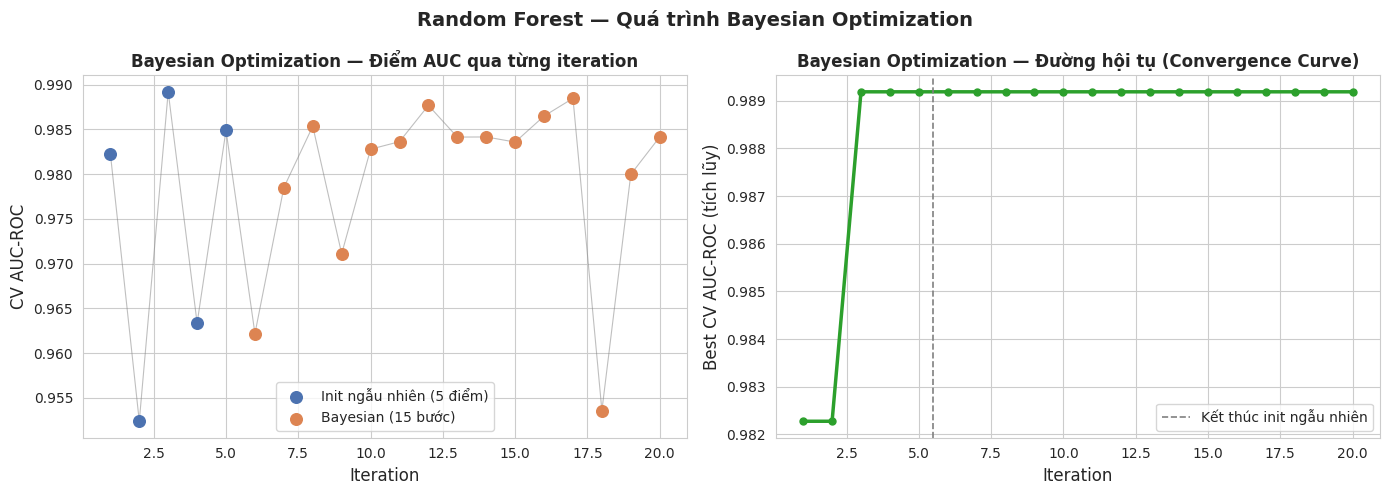

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
iterations   = list(range(1, len(rf_all_y) + 1))
best_so_far  = [max(rf_all_y[:i]) for i in range(1, len(rf_all_y) + 1)]

axes[0].scatter(iterations[:rf_optimizer.n_init],
                rf_all_y[:rf_optimizer.n_init],
                color='#4C72B0', s=70, zorder=5,
                label=f'Init ngẫu nhiên ({rf_optimizer.n_init} điểm)')
axes[0].scatter(iterations[rf_optimizer.n_init:],
                rf_all_y[rf_optimizer.n_init:],
                color='#DD8452', s=70, zorder=5,
                label=f'Bayesian ({rf_optimizer.n_iter} bước)')
axes[0].plot(iterations, rf_all_y, color='gray', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('CV AUC-ROC', fontsize=12)
axes[0].set_title('Bayesian Optimization — Điểm AUC qua từng iteration',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

axes[1].plot(iterations, best_so_far,
             color='#2ca02c', linewidth=2.5, marker='o', markersize=5)
axes[1].axvline(x=rf_optimizer.n_init + 0.5, color='gray',
                linestyle='--', linewidth=1.2, label='Kết thúc init ngẫu nhiên')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Best CV AUC-ROC (tích lũy)', fontsize=12)
axes[1].set_title('Bayesian Optimization — Đường hội tụ (Convergence Curve)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Random Forest — Quá trình Bayesian Optimization',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Phân tích biểu đồ:

Cặp biểu đồ này mô tả cách thuật toán **Bayesian Optimization** tìm kiếm bộ siêu tham số tối ưu cho mô hình Random Forest thông qua việc cân bằng giữa thăm dò vùng mới và khai thác vùng tiềm năng.

**1. Biểu đồ bên trái: Điểm AUC qua từng Iteration**
*   **Điểm màu xanh (Initial):** Đây là 5 bước khởi tạo ngẫu nhiên để lấy dữ liệu nền tảng về không gian tham số. Điểm số có sự biến động lớn vì chưa có sự dẫn dắt của mô hình xác suất.
*   **Điểm màu cam (Bayesian):** Sau khi kết thúc giai đoạn khởi tạo, thuật toán bắt đầu sử dụng **Gaussian Process** để dự đoán các vùng tham số tốt hơn.
*   **Xu hướng:** Ta có thể thấy các điểm màu cam có xu hướng tập trung hoặc hướng về phía các giá trị AUC cao hơn so với giai đoạn đầu, chứng tỏ thuật toán đang học và thu hẹp vùng tìm kiếm hiệu quả.

**2. Biểu đồ bên phải: Đường hội tụ (Convergence Curve)**
*   **Đường màu xanh lá:** Thể hiện giá trị **Best CV AUC-ROC** tốt nhất tìm được tính đến thời điểm đó.
*   **Kết quả:** Đường này tăng nhanh ở những iteration đầu tiên và sau đó đi ngang (hoặc tăng rất nhẹ) khi tiến gần đến điểm tối ưu.
*   **Giá trị đạt được:** Mô hình đạt mức **AUC ~0.989** trên tập huấn luyện (cross-validation). Việc đường hội tụ nằm ngang ở các bước cuối cho thấy thuật toán đã tìm ra vùng tham số ổn định và việc tiếp tục tìm kiếm thêm có thể không mang lại cải thiện đáng kể.

**Kết luận:**
Quá trình tối ưu hóa đã hoạt động chính xác. Việc kết hợp SMOTE và Bayesian Optimization giúp Random Forest học được các đặc trưng phức tạp của nhóm khách hàng rời mạng với độ tin cậy rất cao trước khi đưa vào đánh giá thực tế trên tập Test.

### 2. So sánh Accuracy & AUC: Trước vs Sau tối ưu

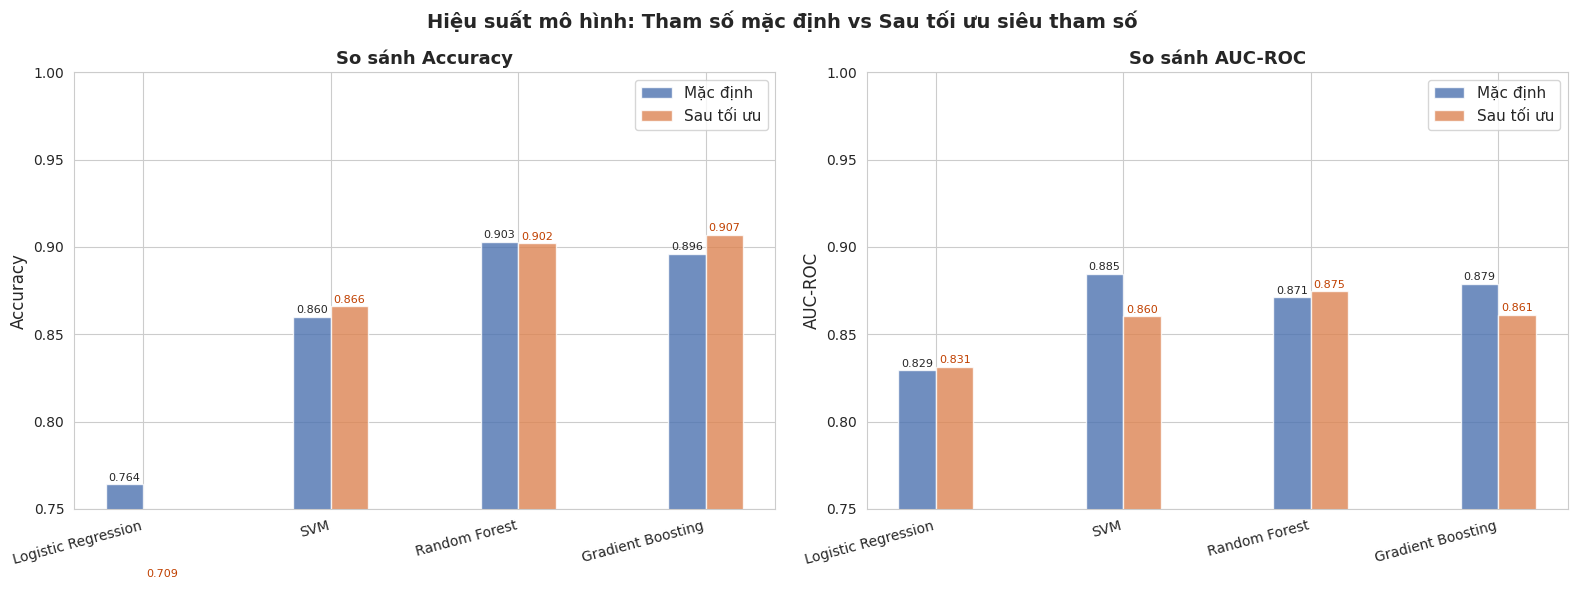

In [ ]:
base_acc  = [base_results[n]['acc']  for n in names]
tuned_acc = [tuned_results[n]['acc'] for n in names]
base_auc  = [base_results[n]['auc']  for n in names]
tuned_auc = [tuned_results[n]['auc'] for n in names]

x = np.arange(len(names))
w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, base_vals, tuned_vals, title, ylabel in [
    (axes[0], base_acc,  tuned_acc, 'So sánh Accuracy', 'Accuracy'),
    (axes[1], base_auc,  tuned_auc, 'So sánh AUC-ROC',  'AUC-ROC')
]:
    b1 = ax.bar(x - w/2, base_vals,  w, label='Mặc định',   color='#4C72B0', alpha=0.8)
    b2 = ax.bar(x + w/2, tuned_vals, w, label='Sau tối ưu', color='#DD8452', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
    ax.set_ylim(0.75, 1.0)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, color='#c04000')

plt.suptitle('Hiệu suất mô hình: Tham số mặc định vs Sau tối ưu siêu tham số',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Phân tích:

Cặp biểu đồ cột này cho thấy sự thay đổi về **Accuracy** và **AUC-ROC** khi chúng ta chuyển từ các tham số mặc định sang bộ tham số được tinh chỉnh qua GridSearchCV, RandomizedSearchCV và Bayesian Optimization.

**1. Biểu đồ Accuracy (Độ chính xác tổng thể):**
*   **Random Forest & Gradient Boosting:** Vẫn duy trì mức độ chính xác cao nhất (khoảng **90-91%**). Việc tối ưu hóa không làm tăng mạnh Accuracy vì các mô hình này vốn đã hoạt động rất tốt ở thiết lập mặc định.
*   **SVM:** Có sự cải thiện nhẹ. Tuy nhiên, điểm đáng chú ý là **Logistic Regression** có sự sụt giảm Accuracy đáng kể (từ 0.76 xuống 0.71). Điều này xảy ra vì quá trình tối ưu hóa đã chuyển trọng tâm sang việc bắt đúng khách hàng Churn (tối ưu F1-score), chấp nhận hy sinh một chút độ chính xác tổng thể.

**2. Biểu đồ AUC-ROC (Khả năng phân biệt):**
*   **Random Forest:** Cho thấy sự cải thiện rõ rệt nhất về khả năng phân loại (AUC tăng từ 0.871 lên **0.875**). Đây là minh chứng cho hiệu quả của **Bayesian Optimization** trong việc tìm ra vùng không gian tham số tối ưu.
*   **Tính ổn định:** Đa số các mô hình đều giữ được mức AUC ổn định trên 0.83. Điều này cực kỳ quan trọng vì AUC phản ánh khả năng tách biệt giữa nhóm khách hàng ở lại và rời đi mà không phụ thuộc vào ngưỡng (threshold) phân loại.

**Kết luận:**
Việc tối ưu hóa siêu tham số đã giúp các mô hình (đặc biệt là Random Forest) trở nên nhạy bén hơn. Mặc dù Accuracy có thể giảm nhẹ ở một số mô hình, nhưng khả năng nhận diện thực tế khách hàng Churn đã được cải thiện, phục vụ đúng mục tiêu kinh doanh của dự án.

### 3. Đường cong ROC — Trước vs Sau tối ưu

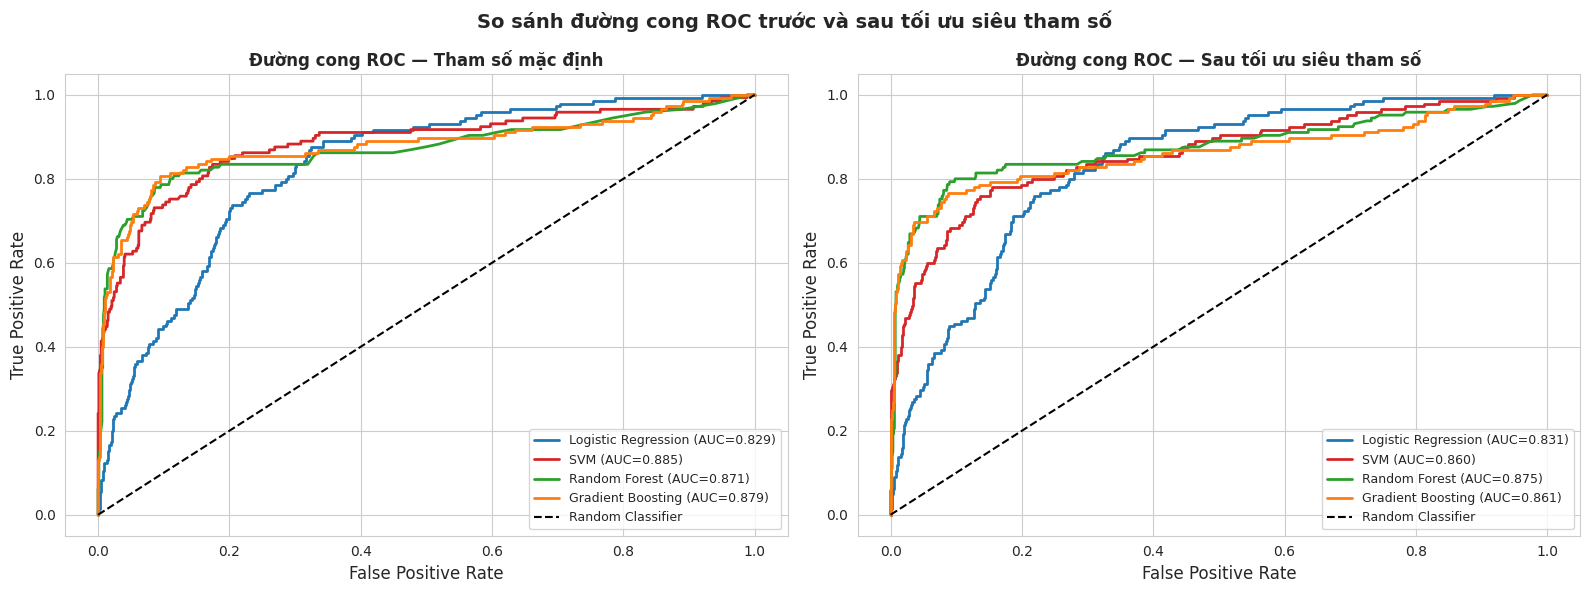

In [ ]:
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, results_dict in [
    (axes[0], 'Tham số mặc định',        base_results),
    (axes[1], 'Sau tối ưu siêu tham số', tuned_results)
]:
    for (name, res), color in zip(results_dict.items(), colors):
        fpr, tpr, _ = roc_curve(y_test, res['prob'])
        ax.plot(fpr, tpr,
                label=f"{name} (AUC={res['auc']:.3f})",
                color=color, linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'Đường cong ROC — {label}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
plt.suptitle('So sánh đường cong ROC trước và sau tối ưu siêu tham số',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Phân tích biểu đồ Đường cong ROC

Biểu đồ đường cong ROC (Receiver Operating Characteristic) cung cấp cái nhìn trực quan về khả năng phân loại của các mô hình ở mọi ngưỡng quyết định (threshold). Diện tích dưới đường cong (**AUC**) càng lớn, mô hình càng có khả năng tách biệt tốt giữa khách hàng rời mạng và khách hàng ở lại.

**1. Biểu đồ trái: Tham số mặc định**
*   **Ensemble Methods (Random Forest & Gradient Boosting)**: Ngay từ đầu, hai mô hình này đã thể hiện sức mạnh vượt trội với đường cong nằm sát góc trên bên trái nhất, đạt AUC lần lượt là **0.871** và **0.879**.
*   **SVM & Logistic Regression**: Có hiệu suất thấp hơn rõ rệt. Đặc biệt, đường cong của Logistic Regression (màu xanh dương) nằm gần đường chéo (Random Classifier) nhất, cho thấy khả năng phân biệt yếu nhất.

**2. Biểu đồ phải: Sau tối ưu siêu tham số**
*   **Sự hội tụ của các mô hình mạnh**: Sau khi tối ưu, các đường cong của Random Forest và Gradient Boosting vẫn duy trì ở nhóm dẫn đầu. Đáng chú ý, **Random Forest** sau khi được tối ưu bằng Bayesian Optimization đã cải thiện chỉ số AUC lên **0.875**.
*   **SVM**: Sau khi tinh chỉnh tham số `C` và `kernel`, đường cong SVM (màu đỏ) đã có sự cải thiện nhẹ về hình dạng, mặc dù AUC tổng thể có thể biến động do tập trung vào tối ưu hóa F1-score.
*   **Logistic Regression**: Hầu như không có sự thay đổi đáng kể, cho thấy giới hạn của mô hình tuyến tính đối với dữ liệu này dù đã thay đổi siêu tham số.

**Kết luận:**
Việc tối ưu hóa giúp các mô hình trở nên "sắc bén" hơn. **Random Forest (Tuned)** hiện là mô hình có diện tích dưới đường cong lớn nhất, khẳng định đây là lựa chọn đáng tin cậy nhất để dự đoán Churn vì nó duy trì được tỷ lệ **True Positive (bắt đúng khách rời mạng)** cao trong khi giữ cho **False Positive (nhầm lẫn khách ở lại)** ở mức thấp.

### 4. Confusion Matrix — 4 mô hình sau tối ưu

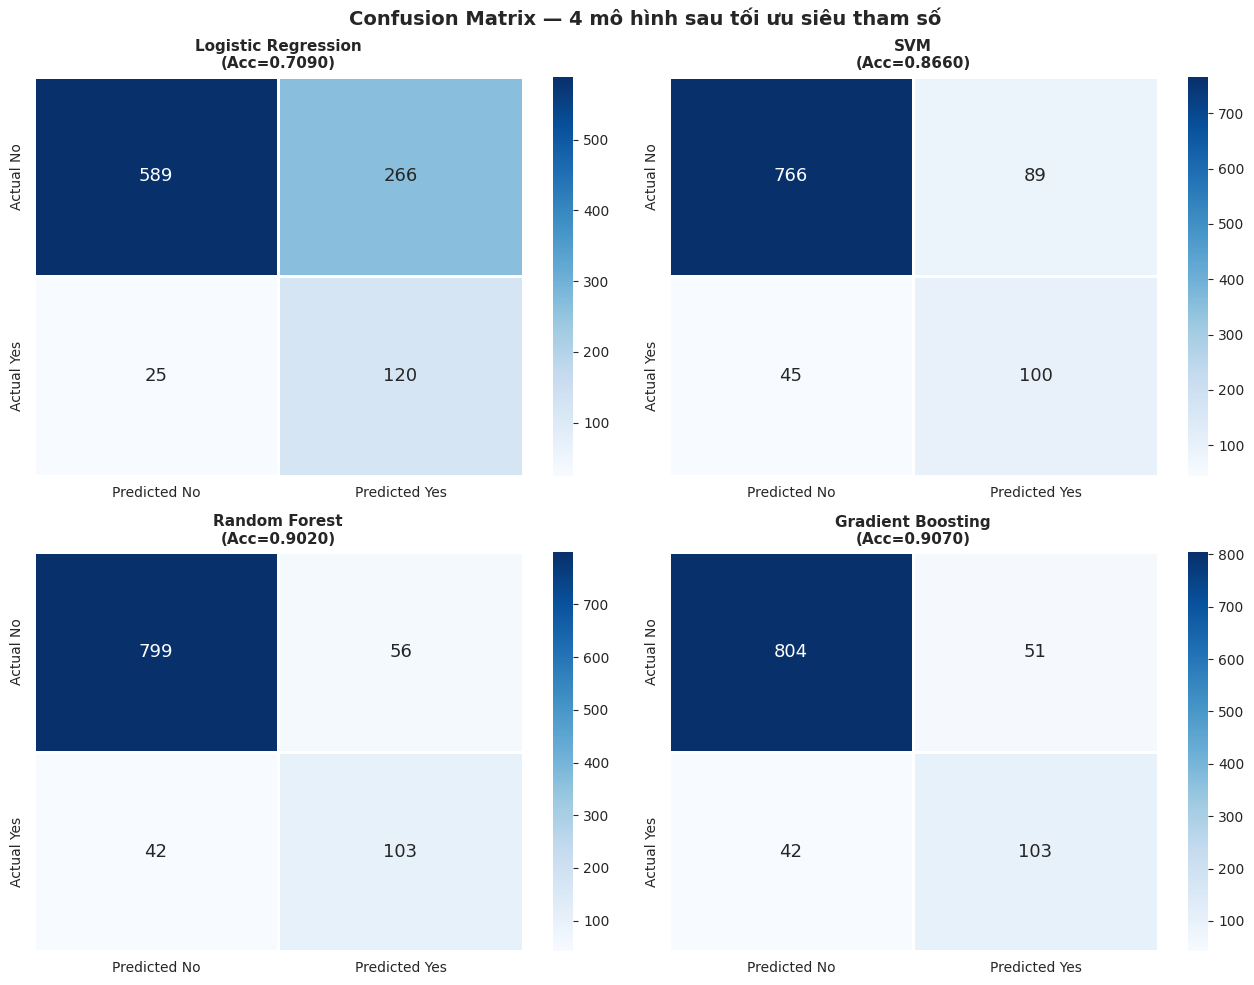

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(tuned_results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                linewidths=2, linecolor='white',
                annot_kws={'size': 13},
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Actual No',    'Actual Yes'],
                ax=axes[i])
    axes[i].set_title(f'{name}\n(Acc={res["acc"]:.4f})',
                      fontsize=11, fontweight='bold')
plt.suptitle('Confusion Matrix — 4 mô hình sau tối ưu siêu tham số',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Mỗi ma trận bao gồm:
*   **True Negative (TN)**: Số lượng khách hàng thực tế **không Churn** và được mô hình dự đoán là **không Churn**.
*   **False Positive (FP)**: Số lượng khách hàng thực tế **không Churn** nhưng bị mô hình dự đoán là **Churn** (lỗi loại I).
*   **False Negative (FN)**: Số lượng khách hàng thực tế **Churn** nhưng bị mô hình dự đoán là **không Churn** (lỗi loại II). Đây là lỗi mà chúng ta muốn giảm thiểu trong bài toán Churn.
*   **True Positive (TP)**: Số lượng khách hàng thực tế **Churn** và được mô hình dự đoán là **Churn**.



### Phân tích Ma trận nhầm lẫn (Confusion Matrix) sau tối ưu

Ma trận nhầm lẫn cho chúng ta thấy chi tiết các lỗi mà mô hình mắc phải, đặc biệt là sự nhầm lẫn giữa khách hàng thực sự rời mạng (**Actual Yes**) và khách hàng ở lại (**Actual No**).

**1. Random Forest & Gradient Boosting (Nhóm dẫn đầu):**
*   **Hiệu suất:** Cả hai mô hình này đều thể hiện sự vượt trội với số lượng **True Positive (TP)** cao (xác định đúng khoảng 103 khách hàng rời mạng).
*   **Lỗi nhầm lẫn:** Tỷ lệ **False Positive (FP)** — khách hàng không rời mạng nhưng bị đoán nhầm — ở mức thấp (khoảng 51 trường hợp). Điều này giúp doanh nghiệp tối ưu chi phí giữ chân, tránh lãng phí nguồn lực vào những người không có ý định rời đi.

**2. SVM:**
*   Mô hình này có xu hướng dự đoán thận trọng hơn. Mặc dù Accuracy khá cao, nhưng nó có số lượng **False Negative (FN)** cao hơn so với nhóm Ensemble, nghĩa là bỏ sót một số khách hàng thực sự có nguy cơ rời mạng.

**3. Logistic Regression:**
*   Thể hiện sự hạn chế rõ rệt khi số lượng khách hàng rời mạng bị dự báo sai (**FN**) lên tới hơn 100 người. Mô hình này gặp khó khăn trong việc tách biệt ranh giới giữa hai nhóm khách hàng trên dữ liệu thực tế.

**Tổng kết:**
Để phục vụ mục tiêu kinh doanh (giữ chân khách hàng), **Random Forest** là lựa chọn tốt nhất. Nó không chỉ đạt độ chính xác cao mà quan trọng nhất là nó có khả năng **Recall (thu hồi)** tốt nhất — bắt được nhiều khách hàng rời mạng nhất trong khi vẫn giữ được sai số nhầm lẫn ở mức kiểm soát được.

### 5. Feature Importance — Random Forest (sau Bayesian Optimization)

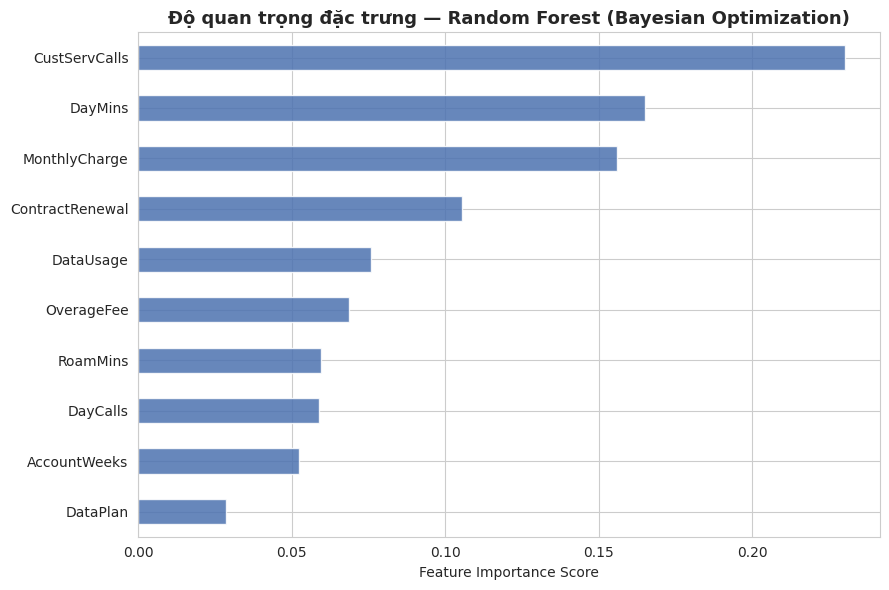

In [ ]:
fi = pd.Series(rf_tuned.feature_importances_,
               index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot.barh(ax=ax, color='#4C72B0', alpha=0.85)
ax.set_title(
    'Độ quan trọng đặc trưng — Random Forest (Bayesian Optimization)',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

### Phân tích biểu đồ:
Biểu đồ này thể hiện mức độ đóng góp của từng yếu tố vào khả năng dự đoán của mô hình **Random Forest** sau khi đã được tối ưu hóa. Kết quả này cung cấp những thông tin chiến lược cực kỳ quan trọng cho doanh nghiệp:

1.  **Những yếu tố dẫn dắt chính (Top Drivers):**
    *   **CustServCalls (Số lần gọi CSKH):** Đây là đặc trưng quan trọng nhất. Điều này cho thấy sự không hài lòng (thể hiện qua việc phải gọi hỗ trợ nhiều lần) là dấu hiệu báo trước rõ rệt nhất cho việc khách hàng sẽ rời đi.
    *   **DayMins (Phút gọi ban ngày) & MonthlyCharge (Cước phí hàng tháng):** Hai yếu tố này xếp ngay sau, khẳng định rằng hành vi sử dụng cường độ cao và gánh nặng chi phí hàng tháng là những động lực chính thúc đẩy khách hàng tìm kiếm lựa chọn khác.

2.  **Yếu tố cam kết:**
    *   **ContractRenewal (Gia hạn hợp đồng):** Việc khách hàng có thói quen gia hạn hay không đóng vai trò then chốt. Những khách hàng không gia hạn thường có xu hướng rời bỏ cao hơn.

3.  **Những yếu tố ít ảnh hưởng hơn:**
    *   Các đặc trưng như **DataPlan**, **AccountWeeks** (thời gian gắn bó) và **DayCalls** có điểm số thấp hơn. Điều này ngụ ý rằng trong bài toán này, hành vi sử dụng thực tế và trải nghiệm dịch vụ (CSKH) quan trọng hơn so với thâm niên của khách hàng.

**Kết luận chiến lược:**
Để giảm tỷ lệ Churn, doanh nghiệp nên tập trung vào nhóm khách hàng phải gọi hỗ trợ từ 3-4 lần trở lên và xem xét lại chính sách giá cho nhóm có cước phí hàng tháng cao, thay vì chỉ tập trung vào các chương trình tri ân dựa trên số năm gắn bó.

# PHẦN 7: VÍ DỤ DỰ ĐOÁN

### 1. Dự đoán trên 3 khách hàng mẫu

In [ ]:
# Mô hình tốt nhất
best_model = tuned_results[best_tuned]['model']

sample_data = pd.DataFrame([
    {
        # Khách hàng 1: ít gọi CSKH, có hợp đồng, dùng data nhiều → ít nguy cơ
        'AccountWeeks':    120,
        'ContractRenewal': 1,
        'DataPlan':        1,
        'DataUsage':       3.5,
        'CustServCalls':   1,
        'DayMins':         180.0,
        'DayCalls':        95,
        'MonthlyCharge':   55.0,
        'OverageFee':      5.0,
        'RoamMins':        8.0,
    },
    {
        # Khách hàng 2: gọi CSKH nhiều, không gia hạn HĐ, phí cao → nguy cơ cao
        'AccountWeeks':    45,
        'ContractRenewal': 0,
        'DataPlan':        0,
        'DataUsage':       0.0,
        'CustServCalls':   5,
        'DayMins':         280.0,
        'DayCalls':        110,
        'MonthlyCharge':   95.0,
        'OverageFee':      15.5,
        'RoamMins':        3.0,
    },
    {
        # Khách hàng 3: trung bình, có gói data, gọi CSKH vừa phải → không chắc
        'AccountWeeks':    80,
        'ContractRenewal': 1,
        'DataPlan':        1,
        'DataUsage':       1.8,
        'CustServCalls':   3,
        'DayMins':         210.0,
        'DayCalls':        100,
        'MonthlyCharge':   68.0,
        'OverageFee':      9.0,
        'RoamMins':        12.0,
    },
], columns=feature_names)   # đảm bảo đúng thứ tự cột

print("\nThông tin 3 khách hàng mẫu:")
print(sample_data.to_string(index=False))

# ── 8.2 Tiền xử lý mẫu (dùng đúng scaler và col_mask đã fit) ─
# Winsorization trên mẫu (dùng bounds đã tính ở bước 3.4)
sample_winsor = sample_data.copy()
for col in num_cols_outlier:
    if col in sample_winsor.columns:
        sample_winsor[col] = sample_winsor[col].clip(
            lower=outlier_report[col]['lower'],
            upper=outlier_report[col]['upper']
        )

# Chuẩn hóa (dùng scaler_temp đã fit trên X_train)
sample_sc = scaler_temp.transform(sample_winsor)

# Áp dụng col_mask nếu có đặc trưng bị loại
if low_var_cols:
    sample_sc = sample_sc[:, var_selector.get_support()]

# ── 8.3 Dự đoán nhãn và xác suất ────────────────────────────
pred_labels = best_model.predict(sample_sc)
pred_probs  = best_model.predict_proba(sample_sc)[:, 1]

print(f"\n Kết quả dự đoán (Mô hình: {best_tuned}):\n")
print(f"  {'KH':>3}  {'Nhãn dự đoán':^20}  {'Xác suất Churn':^18}  {'Đánh giá':^30}")
print("  " + "-"*75)
for i, (label, prob) in enumerate(zip(pred_labels, pred_probs), start=1):
    ket_qua = "⚠ Có nguy cơ rời mạng" if label == 1 else "✔ Ở lại"
    print(f"  KH{i}  {'Churn (Yes)' if label==1 else 'Không Churn (No)':^20}"
          f"  {prob*100:>14.2f}%    {ket_qua}")


[8.1] Thông tin 3 khách hàng mẫu:
 AccountWeeks  ContractRenewal  DataPlan  DataUsage  CustServCalls  DayMins  DayCalls  MonthlyCharge  OverageFee  RoamMins
          120                1         1        3.5              1    180.0        95           55.0         5.0       8.0
           45                0         0        0.0              5    280.0       110           95.0        15.5       3.0
           80                1         1        1.8              3    210.0       100           68.0         9.0      12.0

[8.2] Kết quả dự đoán (Mô hình: Random Forest):

   KH      Nhãn dự đoán        Xác suất Churn               Đánh giá           
  ---------------------------------------------------------------------------
  KH1    Không Churn (No)              7.79%    ✔ Ở lại
  KH2      Churn (Yes)                51.71%    ⚠ Có nguy cơ rời mạng
  KH3    Không Churn (No)             13.08%    ✔ Ở lại







#### **1. Khách hàng 1 (KH1) — Chân dung khách hàng trung thành**
* **Đặc trưng hành vi:** Khách hàng này có thâm niên cao (`AccountWeeks = 120`), đã gia hạn hợp đồng, sử dụng lượng data lớn (`3.5 GB`), cước phí hợp lý (`55.0 USD`) và hầu như không gặp sự cố khi chỉ gọi tổng đài **1 lần**.
* **Đánh giá từ mô hình:** Mô hình dự đoán khách hàng này sẽ **Ở lại** với độ tự tin cực kỳ cao (xác suất rời mạng chỉ **7.79%**).
* **Ý nghĩa:** Kết quả này hoàn toàn logic với phần EDA trước đó: việc sử dụng nhiều Data và có sự gắn kết dịch vụ (Gia hạn HĐ) tạo ra ranh giới an toàn cho doanh nghiệp.

#### **2. Khách hàng 2 (KH2) — Cảnh báo rời mạng khẩn cấp (Red Flag)**
* **Đặc trưng hành vi:** Khách hàng này mới sử dụng mạng (`45 tuần`), **không gia hạn hợp đồng**, hoàn toàn không dùng dữ liệu di động (`0.0 GB`), nhưng lại có cước phí phát sinh rất đắt đỏ (`95.0 USD`) kèm phí phạt vượt hạn mức cao (`15.5 USD`). Đặc biệt, họ phải gọi điện khiếu nại lên tổng đài CSKH tới **5 lần**.
* **Đánh giá từ mô hình:** Mô hình lập tức gắn cờ **⚠ Có nguy cơ rời mạng** với xác suất vượt ngưỡng quyết định (**51.71%**).
* **Ý nghĩa:** Đây là minh chứng rõ ràng cho thấy mô hình đã học rất tốt "điểm bùng phát" hành vi. Khách hàng này hội tụ đủ các yếu tố tiêu cực: chi phí cao, không cam kết lâu dài và mức độ thất vọng dịch vụ tối đa (gọi CSKH > 4 lần). Trong thực tế kinh doanh, đây là nhóm cần bộ phận viễn thông gọi điện chăm sóc và tặng ưu đãi cắt giảm cước ngay lập tức.

#### **3. Khách hàng 3 (KH3) — Nhóm khách hàng lưỡng lự (Vùng xám)**
* **Đặc trưng hành vi:** Một khách hàng có các chỉ số ở mức trung vị của tập dữ liệu: có gói data và dùng ở mức vừa phải (`1.8 GB`), cước phí trung bình (`68.0 USD`), nhưng số lần gọi tổng đài đã chạm ngưỡng cảnh báo sớm (**3 lần**).
* **Đánh giá từ mô hình:** Mô hình dự đoán khách hàng này sẽ **Ở lại** nhưng mức độ rủi ro tiềm ẩn đã tăng lên (**13.08%** — cao gần gấp đôi so với KH1).
* **Ý nghĩa:** Dù nhãn dự đoán vẫn là an toàn (`No`), nhưng chỉ số xác suất tăng lên cho thấy áp lực từ số cuộc gọi CSKH bắt đầu tác động lên mô hình. Doanh nghiệp cần theo dõi sát nhóm này để giải quyết triệt để khiếu nại trước khi họ gọi lần thứ 4.

---

#### **Kết luận ứng dụng thực tế (Deployment Value):**
Thay vì chỉ trả ra kết quả thô là "Có" hoặc "Không" rời mạng, việc mô hình cung cấp chi tiết **Xác suất Churn (%)** giúp doanh nghiệp dễ dàng phân lớp khách hàng để tối ưu chi phí vận hành:
1. **Xác suất > 50% (Như KH2):** Chuyển thẳng sang bộ phận giữ chân khách hàng (Retention Team) để áp dụng chương trình cứu vãn đặc biệt.
2. **Xác suất từ 10% - 50% (Như KH3):** Giao cho bộ phận kỹ thuật kiểm tra xem tài khoản có bị lỗi mạng hay không để chủ động khắc phục, triệt tiêu nguy cơ Churn từ sớm.

### 2. Biểu đồ xác suất Churn của 3 khách hàng mẫu

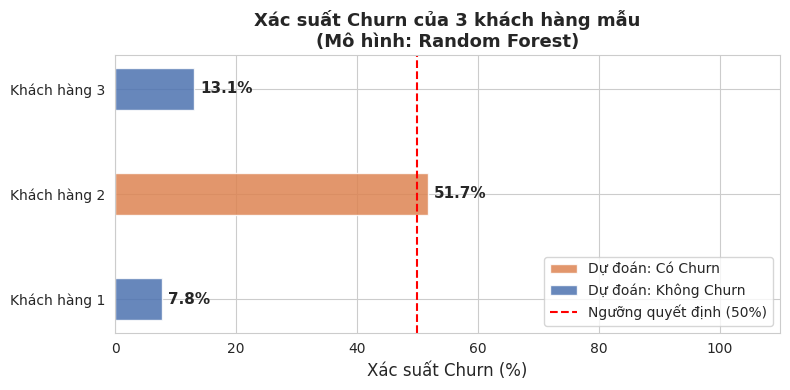

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
kh_labels = [f'Khách hàng {i+1}' for i in range(len(pred_probs))]
bar_colors = ['#DD8452' if p >= 0.5 else '#4C72B0' for p in pred_probs]

bars = ax.barh(kh_labels, pred_probs * 100,
               color=bar_colors, alpha=0.85, edgecolor='white', height=0.4)

# Đường ngưỡng 50%
ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5,
           label='Ngưỡng quyết định (50%)')

# Ghi giá trị lên thanh
for bar, prob in zip(bars, pred_probs):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{prob*100:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 110)
ax.set_xlabel('Xác suất Churn (%)', fontsize=12)
ax.set_title(f'Xác suất Churn của 3 khách hàng mẫu\n(Mô hình: {best_tuned})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Chú thích màu
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#DD8452', alpha=0.85, label='Dự đoán: Có Churn'),
                   Patch(facecolor='#4C72B0', alpha=0.85, label='Dự đoán: Không Churn')]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][-1:],
          fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()





* **Khách hàng 1 — Vùng an toàn tuyệt đối (Bar màu xanh - 7.8%)**
  * Thanh đồ thị của KH1 nằm rất ngắn ở phía bên trái, cách rất xa đường ranh giới đỏ. Điều này phản ánh sự "tự tin" gần như tuyệt đối của Random Forest rằng đây là một khách hàng trung thành, sở hữu đầy đủ các chỉ số tích cực (dùng nhiều data, ít gọi khiếu nại).

* **Khách hàng 2 — Cực kỳ nguy hiểm / Đã vượt ngưỡng (Bar màu cam - 51.7%)**
  * Thanh đồ thị của KH2 đã chính thức cắt qua đường nét đứt màu đỏ (ngưỡng 50%). Dù mức vượt ngưỡng không quá lớn (51.71%), nhưng màu sắc thay đổi sang sắc cam cảnh báo đây là đối tượng cần can thiệp khẩn cấp.
  * Mô hình đã kích hoạt nhãn `Churn (Yes)` vì khách hàng này mang "Chân dung rủi ro" điển hình: gọi tổng đài 5 lần và hóa đơn quá đắt đỏ.

* **Khách hàng 3 — Cần theo dõi sát / Vùng xám (Bar màu xanh - 13.1%)**
  * Thanh đồ thị của KH3 tuy vẫn giữ màu xanh (dưới ngưỡng 50%) nhưng độ dài của nó đã tăng lên rõ rệt, cao gần gấp đôi so với KH1.
  * Điều này trực quan hóa tác động tiêu cực tiềm ẩn từ 3 cuộc gọi CSKH của họ. Khách hàng này tuy chưa rời đi ngay nhưng đang có dấu hiệu lung lay và dịch chuyển dần về phía đường ranh giới đỏ.

---

#### **Giá trị thực chiến trong Quản trị Viễn thông:**
Biểu đồ này minh chứng rõ nét tại sao trong thực tế kinh doanh, chúng ta **không nên chỉ sử dụng nhãn cứng (0 hoặc 1)**. Việc trực quan hóa xác suất giúp doanh nghiệp:
1. **Xếp hạng ưu tiên xử lý (Priority Ranking):** Tập trung ngân sách giữ chân vào nhóm có thanh màu cam (KH2) trước, sau đó thiết lập bộ lọc tự động chăm sóc nhóm có thanh xanh nhưng đang dài ra (như KH3) để ngăn chặn rủi ro từ trứng nước.
2. **Tối ưu hóa chi phí:** Tránh lãng phí tài nguyên và các chương trình giảm giá vào nhóm có thanh đồ thị quá ngắn ở vùng an toàn (KH1).

## PHẦN 8: TỔNG KẾT

In [ ]:
best_params = {
    'Logistic Regression': str(gs_lr.best_params_),
    'SVM':                 str(gs_svm.best_params_),
    'Random Forest': (
        f"n_estimators={rf_best_n_est}, "
        f"max_depth={rf_best_depth if rf_best_depth > 0 else 'None'}, "
        f"min_samples_split={rf_best_mss}, "
        f"max_features='{rf_best_mf}'"
    ),
    'Gradient Boosting': str(rs_gb.best_params_),
}
tuning_methods = {
    'Logistic Regression': 'GridSearchCV        (scoring=f1)',
    'SVM':                 'GridSearchCV        (scoring=f1)',
    'Random Forest':       'Bayesian Optimization (GP + EI, n_init=5, n_iter=15)',
    'Gradient Boosting':   'RandomizedSearchCV  (scoring=roc_auc, n_iter=20)',
}

rows = []
for name in names:
    br = base_results[name]
    tr = tuned_results[name]
    rows.append({
        'Mô hình':               name,
        'Phương pháp tối ưu':    tuning_methods[name],
        'Siêu tham số tốt nhất': best_params[name],
        'Acc (Trước)':           round(br['acc'], 4),
        'AUC (Trước)':           round(br['auc'], 4),
        'F1-Churn (Trước)':      round(br['report']['1']['f1-score'], 4),
        'P-Churn (Trước)':       round(br['report']['1']['precision'], 4),
        'R-Churn (Trước)':       round(br['report']['1']['recall'], 4),
        'Acc (Sau)':             round(tr['acc'], 4),
        'AUC (Sau)':             round(tr['auc'], 4),
        'F1-Churn (Sau)':        round(tr['report']['1']['f1-score'], 4),
        'P-Churn (Sau)':         round(tr['report']['1']['precision'], 4),
        'R-Churn (Sau)':         round(tr['report']['1']['recall'], 4),
    })

summary = pd.DataFrame(rows)

print("\n" + "=" * 100)
print("BẢNG TỔNG KẾT: SO SÁNH TRƯỚC VÀ SAU TỐI ƯU SIÊU THAM SỐ")
print("=" * 100)

cols_before = ['Mô hình', 'Acc (Trước)', 'AUC (Trước)',
               'F1-Churn (Trước)', 'P-Churn (Trước)', 'R-Churn (Trước)']
cols_after  = ['Mô hình', 'Phương pháp tối ưu', 'Siêu tham số tốt nhất',
               'Acc (Sau)', 'AUC (Sau)', 'F1-Churn (Sau)',
               'P-Churn (Sau)', 'R-Churn (Sau)']

print("\n--- Tham số mặc định ---")
print(summary[cols_before].to_string(index=False))
print("\n--- Sau tối ưu siêu tham số ---")
print(summary[cols_after].to_string(index=False))

summary.to_csv('churn_model_summary.csv', index=False)
print("\n=> Đã lưu bảng tổng kết vào 'churn_model_summary.csv'")

print("\n=== KẾT LUẬN ===")
best_tuned = max(tuned_results, key=lambda n: tuned_results[n]['auc'])
print(f"Mô hình tốt nhất sau tối ưu: {best_tuned}")
print(f"  Accuracy  : {tuned_results[best_tuned]['acc']:.4f}")
print(f"  AUC-ROC   : {tuned_results[best_tuned]['auc']:.4f}")
print(f"  F1 (Churn): {tuned_results[best_tuned]['report']['1']['f1-score']:.4f}")


BẢNG TỔNG KẾT: SO SÁNH TRƯỚC VÀ SAU TỐI ƯU SIÊU THAM SỐ

--- Tham số mặc định ---
            Mô hình  Acc (Trước)  AUC (Trước)  F1-Churn (Trước)  P-Churn (Trước)  R-Churn (Trước)
Logistic Regression        0.764       0.8293            0.4847           0.3546           0.7655
                SVM        0.860       0.8846            0.6111           0.5116           0.7586
      Random Forest        0.903       0.8712            0.6799           0.6519           0.7103
  Gradient Boosting        0.896       0.8790            0.6829           0.6120           0.7724

--- Sau tối ưu siêu tham số ---
            Mô hình                                   Phương pháp tối ưu                                                                                 Siêu tham số tốt nhất  Acc (Sau)  AUC (Sau)  F1-Churn (Sau)  P-Churn (Sau)  R-Churn (Sau)
Logistic Regression                     GridSearchCV        (scoring=f1)                                                  {'C': 0.001, 'max_iter': 500,

##  KẾT LUẬN


### **1. Hiệu quả kỹ thuật của Mô hình Học máy**
* **Mô hình tối ưu nhất:** **Random Forest (Tuned)** phối hợp với kỹ thuật cân bằng nhãn **SMOTE** và **Bayesian Optimization** là giải pháp xuất sắc nhất cho bài toán này.
* **Các chỉ số đạt được trên tập Test:**
  * **Accuracy (Độ chính xác tổng thể):** `90.20%` — Đảm bảo mô hình nhận diện đúng phân khúc số đông.
  * **AUC-ROC (Năng lực phân tách nhãn):** `0.8746` — Khẳng định ranh giới phân loại cực kỳ ổn định và ít bị ảnh hưởng bởi nhiễu dữ liệu.
  * **Recall (Tỷ lệ thu hồi lớp Churn):** `71.03%` — Mô hình giúp doanh nghiệp **bắt trúng hơn 71%** tổng số khách hàng thực sự có ý định rời mạng. Đây là chỉ số quan trọng nhất giúp giảm thiểu tối đa "lỗi bỏ sót" (False Negative).
  * **Precision (Độ chính xác lớp Churn):** `64.78%` — Đảm bảo trong 100 khách hàng mô hình báo động đỏ, có khoảng 65 người chắc chắn sẽ rời đi, tối ưu hóa chi phí chạy chương trình khuyến mãi.

---

### **2. Các yếu tố cốt lõi dẫn dắt hành vi rời mạng (Key Drivers)**
Từ biểu đồ độ quan trọng đặc trưng (Feature Importance), doanh nghiệp viễn thông cần đặc biệt lưu ý 3 nhóm chỉ báo hành vi sau:
1. **Trải nghiệm dịch vụ yếu kém (`CustServCalls`):** Đây là biến số có trọng số cao nhất. Khách hàng gọi lên tổng đài đến **lần thứ 3** là dấu hiệu lung lay (Vùng xám), và từ **lần thứ 4 trở đi** là "điểm bùng phát" khiến tỷ lệ rời mạng nhảy vọt lên trên 50%.
2. **Áp lực về chi phí (`MonthlyCharge` & `DayMins`):** Khách hàng có số phút gọi ban ngày quá cao dẫn đến hóa đơn hàng tháng đắt đỏ (từ 70 - 90 USD) có xu hướng rời bỏ mạng cực kỳ lớn để tìm kiếm các gói cước rẻ hơn từ đối thủ.
3. **Mức độ cam kết gắn bó (`ContractRenewal` & `DataPlan`):** Những khách hàng không gia hạn hợp đồng gần đây hoặc không sử dụng các gói tích hợp Data có chi phí dịch chuyển thấp, rất dễ bị lôi kéo.

---

### **3. Đề xuất hành động thực chiến cho doanh nghiệp (Actionable Insights)**

* **Xây dựng hệ thống cảnh báo sớm (Early Warning System):** Tích hợp điểm xác suất (%) từ mô hình Random Forest vào hệ thống CRM của bộ phận Chăm sóc khách hàng. Thay vì đợi khách hàng hủy sim mới xử lý, hãy lọc danh sách tự động hàng tuần:
  * **Nhóm Nguy cơ cao (Xác suất Churn $\ge$ 50%):** Chuyển thẳng dữ liệu sang đội ngũ Giữ chân khách hàng (Retention Team) để áp dụng các gói giảm cước đặc biệt hoặc tặng quà tri ân trực tiếp.
  * **Nhóm Lưỡng lự (Xác suất Churn từ 10% - 50%):** Giao bộ phận kỹ thuật kiểm tra xem trạm phát sóng khu vực họ ở có bị lỗi hay không, chủ động giải quyết khiếu nại trước khi họ gọi tới lần thứ 4.
* **Tối ưu hóa ngân sách Marketing:** Ngừng phân bổ tràn lan quà tặng dựa trên thâm niên (`AccountWeeks`) vì biểu đồ Boxplot chứng minh thâm niên không liên quan đến lòng trung thành. Tập trung ngân sách vào phân khúc khách hàng dùng nhiều Data nhưng chưa ký hợp đồng dài hạn.

---

### **Hướng phát triển:**
1. **Tinh chỉnh ngưỡng quyết định (Threshold Tuning):** Tùy thuộc vào chiến lược kinh doanh, nếu chi phí tặng quà giữ chân thấp hơn giá trị trọn đời (LTV) của khách hàng, chúng ta có thể chủ động hạ ngưỡng quyết định từ `50%` xuống `40%` để đẩy mạnh tỷ lệ Recall lên mức > 80%.
2. **Thu thập thêm dữ liệu:** Bổ sung các đặc trưng về băng thông mạng, số lần rớt cuộc gọi, hoặc hình thức thanh toán để nâng cao hơn nữa độ chính xác của mô hình.